<a href="https://colab.research.google.com/github/arsalanmontazeri/Arsalan-Montazeri/blob/CDC-Wastewater/CDC_Wastewateripynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_cdc_wastewater_data():
    """
    Load the CDC Wastewater Data for RSV dataset from desktop
    """
    try:
        # Load the dataset
        print("Loading CDC Wastewater Data for RSV dataset...")
        df = pd.read_csv('CDC_Wastewater_Data_for_RSV.csv')

        # Display basic information about the dataset
        print(f"\nDataset loaded successfully!")
        print(f"Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        print(f"\nFirst few rows:")
        print(df.head())

        print(f"\nDataset info:")
        print(df.info())

        print(f"\nBasic statistics:")
        print(df.describe())

        return df

    except FileNotFoundError:
        print("Error: CDC_Wastewater_Data_for_RSV.csv not found on desktop")
        return None
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

if __name__ == "__main__":
    # Load the dataset
    df = load_cdc_wastewater_data()

    if df is not None:
        print(f"\nDataset loaded successfully with {len(df)} rows and {len(df.columns)} columns")
    else:
        print("Failed to load dataset")

Loading CDC Wastewater Data for RSV dataset...

Dataset loaded successfully!
Shape: (46118, 35)
Columns: ['sewershed_id', 'wwtp_jurisdiction', 'county_fips', 'counties_served', 'population_served', 'sample_id', 'sample_collect_date', 'sample_type', 'sample_matrix', 'sample_location', 'flow_rate', 'concentration_method', 'pasteurized', 'pcr_type', 'extraction_method', 'major_lab_method', 'inhibition_detect', 'inhibition_adjust', 'ntc_amplify', 'pcr_target', 'pcr_gene_target_agg', 'pcr_target_avg_conc', 'pcr_target_units', 'lod_sewage', 'pcr_target_avg_conc_lin', 'pcr_target_flowpop_lin', 'pcr_target_mic_lin', 'hum_frac_target_mic', 'hum_frac_mic_conc', 'hum_frac_mic_unit', 'rec_eff_percent', 'rec_eff_target_name', 'rec_eff_spike_matrix', 'rec_eff_spike_conc', 'date_updated']

First few rows:
   sewershed_id wwtp_jurisdiction county_fips  counties_served  \
0           162                ca       06079  San Luis Obispo   
1           679                la       22103    Saint Tammany   


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_missing_values(df):
    """
    Analyze missing values in the dataset
    """
    print("=== MISSING VALUES ANALYSIS ===")

    # Calculate missing values for each column
    missing_data = df.isnull().sum()
    missing_percentage = (missing_data / len(df)) * 100

    missing_summary = pd.DataFrame({
        'Column': missing_data.index,
        'Missing_Count': missing_data.values,
        'Missing_Percentage': missing_percentage.values
    }).sort_values('Missing_Percentage', ascending=False)

    print("\nMissing values summary:")
    print(missing_summary[missing_summary['Missing_Count'] > 0])

    return missing_summary

def categorize_columns_by_missing_pattern(df, missing_summary):
    """
    Categorize columns based on missing value patterns
    """
    print("\n=== COLUMN CATEGORIZATION BY MISSING PATTERNS ===")

    # Columns with no missing values
    complete_columns = missing_summary[missing_summary['Missing_Count'] == 0]['Column'].tolist()

    # Columns with < 5% missing values
    low_missing = missing_summary[(missing_summary['Missing_Count'] > 0) &
                                 (missing_summary['Missing_Percentage'] < 5)]['Column'].tolist()

    # Columns with 5-20% missing values
    medium_missing = missing_summary[(missing_summary['Missing_Percentage'] >= 5) &
                                   (missing_summary['Missing_Percentage'] < 20)]['Column'].tolist()

    # Columns with > 20% missing values
    high_missing = missing_summary[missing_summary['Missing_Percentage'] >= 20]['Column'].tolist()

    print(f"Complete columns (0% missing): {len(complete_columns)}")
    print(f"Low missing (<5%): {len(low_missing)}")
    print(f"Medium missing (5-20%): {len(medium_missing)}")
    print(f"High missing (>20%): {len(high_missing)}")

    return {
        'complete': complete_columns,
        'low_missing': low_missing,
        'medium_missing': medium_missing,
        'high_missing': high_missing
    }

def strategy_1_simple_imputation(df, missing_summary):
    """
    Strategy 1: Simple imputation methods (fixed version)
    """
    print("\n=== STRATEGY 1: SIMPLE IMPUTATION ===")

    df_imputed = df.copy()

    # For numeric columns
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    numeric_missing = [col for col in numeric_columns if missing_summary[missing_summary['Column'] == col]['Missing_Count'].iloc[0] > 0]

    print(f"Numeric columns with missing values: {numeric_missing}")

    for col in numeric_missing:
        missing_pct = missing_summary[missing_summary['Column'] == col]['Missing_Percentage'].iloc[0]

        if missing_pct < 10:
            # For low missing: use median
            median_val = df[col].median()
            df_imputed[col] = df_imputed[col].fillna(median_val)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with median ({median_val:.2f})")
        elif missing_pct < 30:
            # For medium missing: use mean
            mean_val = df[col].mean()
            df_imputed[col] = df_imputed[col].fillna(mean_val)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with mean ({mean_val:.2f})")
        else:
            # For high missing: use 0
            df_imputed[col] = df_imputed[col].fillna(0)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with 0")

    # For categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    categorical_missing = [col for col in categorical_columns if missing_summary[missing_summary['Column'] == col]['Missing_Count'].iloc[0] > 0]

    print(f"\nCategorical columns with missing values: {categorical_missing}")

    for col in categorical_missing:
        missing_pct = missing_summary[missing_summary['Column'] == col]['Missing_Percentage'].iloc[0]

        if missing_pct < 20:
            # For low missing: use mode
            mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
            df_imputed[col] = df_imputed[col].fillna(mode_val)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with mode ('{mode_val}')")
        else:
            # For high missing: use 'Unknown'
            df_imputed[col] = df_imputed[col].fillna('Unknown')
            print(f"  {col}: Filled {missing_pct:.1f}% missing with 'Unknown'")

    return df_imputed

def strategy_2_removal_approach(df, missing_summary):
    """
    Strategy 2: Removal approach
    """
    print("\n=== STRATEGY 2: REMOVAL APPROACH ===")

    # Option 1: Remove rows with any missing values
    df_complete_rows = df.dropna()
    print(f"Option 1 - Remove all rows with missing values:")
    print(f"  Original: {len(df)} rows")
    print(f"  After removal: {len(df_complete_rows)} rows")
    print(f"  Data loss: {((len(df) - len(df_complete_rows)) / len(df) * 100):.1f}%")

    # Option 2: Remove columns with high missing values (>50%)
    high_missing_cols = missing_summary[missing_summary['Missing_Percentage'] > 50]['Column'].tolist()
    df_reduced_cols = df.drop(columns=high_missing_cols)
    print(f"\nOption 2 - Remove columns with >50% missing values:")
    print(f"  Removed columns: {high_missing_cols}")
    print(f"  Original: {len(df.columns)} columns")
    print(f"  After removal: {len(df_reduced_cols.columns)} columns")

    # Option 3: Remove rows with missing values in critical columns only
    critical_columns = ['sewershed_id', 'sample_collect_date', 'pcr_target_avg_conc']
    available_critical = [col for col in critical_columns if col in df.columns]
    df_critical_complete = df.dropna(subset=available_critical)
    print(f"\nOption 3 - Remove rows with missing values in critical columns only:")
    print(f"  Critical columns: {available_critical}")
    print(f"  Original: {len(df)} rows")
    print(f"  After removal: {len(df_critical_complete)} rows")
    print(f"  Data loss: {((len(df) - len(df_critical_complete)) / len(df) * 100):.1f}%")

    return {
        'complete_rows': df_complete_rows,
        'reduced_cols': df_reduced_cols,
        'critical_complete': df_critical_complete
    }

def strategy_3_hybrid_approach(df, missing_summary):
    """
    Strategy 3: Hybrid approach - combination of removal and imputation
    """
    print("\n=== STRATEGY 3: HYBRID APPROACH ===")

    df_hybrid = df.copy()

    # Step 1: Remove columns with >50% missing values
    high_missing_cols = missing_summary[missing_summary['Missing_Percentage'] > 50]['Column'].tolist()
    df_hybrid = df_hybrid.drop(columns=high_missing_cols)
    print(f"Step 1: Removed {len(high_missing_cols)} columns with >50% missing values")

    # Step 2: Remove rows with missing values in critical columns
    critical_columns = ['sewershed_id', 'sample_collect_date', 'pcr_target_avg_conc']
    available_critical = [col for col in critical_columns if col in df_hybrid.columns]
    df_hybrid = df_hybrid.dropna(subset=available_critical)
    print(f"Step 2: Removed rows with missing values in critical columns: {available_critical}")
    print(f"  Remaining rows: {len(df_hybrid)}")

    # Step 3: Impute remaining missing values
    remaining_missing = df_hybrid.isnull().sum()
    remaining_missing_cols = remaining_missing[remaining_missing > 0].index.tolist()

    for col in remaining_missing_cols:
        if df_hybrid[col].dtype in ['int64', 'float64']:
            # Numeric columns: use median
            median_val = df_hybrid[col].median()
            df_hybrid[col] = df_hybrid[col].fillna(median_val)
            print(f"  {col}: Filled with median ({median_val:.2f})")
        else:
            # Categorical columns: use mode
            mode_val = df_hybrid[col].mode()[0] if len(df_hybrid[col].mode()) > 0 else 'Unknown'
            df_hybrid[col] = df_hybrid[col].fillna(mode_val)
            print(f"  {col}: Filled with mode ('{mode_val}')")

    return df_hybrid

def recommend_strategy(missing_summary, column_categories):
    """
    Recommend the best strategy based on missing value patterns
    """
    print("\n=== RECOMMENDED STRATEGY ===")

    high_missing_count = len(column_categories['high_missing'])
    medium_missing_count = len(column_categories['medium_missing'])
    low_missing_count = len(column_categories['low_missing'])

    print(f"Based on missing value analysis:")
    print(f"- High missing columns: {high_missing_count}")
    print(f"- Medium missing columns: {medium_missing_count}")
    print(f"- Low missing columns: {low_missing_count}")

    print("\n=== DETAILED RECOMMENDATIONS ===")

    if high_missing_count > 5:
        print("RECOMMENDATION: Use Strategy 3 (Hybrid Approach)")
        print("Rationale: High number of columns with >20% missing values")
        print("Steps:")
        print("1. Remove columns with >50% missing values (e.g., inhibition_adjust)")
        print("2. Remove rows with missing critical values")
        print("3. Apply simple imputation to remaining missing values")
        print("4. Consider domain-specific imputation for wastewater data")
    elif medium_missing_count > 10:
        print("RECOMMENDATION: Use Strategy 1 (Simple Imputation) with domain knowledge")
        print("Rationale: Moderate missing values across many columns")
        print("Steps:")
        print("1. Use median for numeric variables")
        print("2. Use mode for categorical variables")
        print("3. Consider temporal patterns for time-series data")
    else:
        print("RECOMMENDATION: Use Strategy 1 (Simple Imputation)")
        print("Rationale: Low to moderate missing values")
        print("Steps:")
        print("1. Use median/mean for numeric variables")
        print("2. Use mode for categorical variables")

    print("\n=== DOMAIN-SPECIFIC CONSIDERATIONS ===")
    print("For CDC Wastewater Data:")
    print("1. flow_rate: Consider seasonal patterns and facility capacity")
    print("2. pcr_target_avg_conc: Critical for RSV analysis - use careful imputation")
    print("3. inhibition_adjust: High missing rate suggests measurement challenges")
    print("4. hum_frac_target_mic: Related to human fraction - important for accuracy")
    print("5. rec_eff_percent: Recovery efficiency - affects data quality")

def main():
    """
    Main function to execute missing value handling strategy
    """
    # Load the dataset
    df = load_cdc_wastewater_data()

    if df is None:
        print("Failed to load dataset")
        return

    # Analyze missing values
    missing_summary = analyze_missing_values(df)

    # Categorize columns
    column_categories = categorize_columns_by_missing_pattern(df, missing_summary)

    # Apply different strategies
    df_simple = strategy_1_simple_imputation(df, missing_summary)
    removal_results = strategy_2_removal_approach(df, missing_summary)
    df_hybrid = strategy_3_hybrid_approach(df, missing_summary)

    # Get recommendation
    recommend_strategy(missing_summary, column_categories)

    # Save processed datasets
    df_simple.to_csv('cdc_wastewater_simple_imputed_fixed.csv', index=False)
    removal_results['critical_complete'].to_csv('cdc_wastewater_critical_complete_fixed.csv', index=False)
    df_hybrid.to_csv('cdc_wastewater_hybrid_processed_fixed.csv', index=False)

    print("\n=== PROCESSED DATASETS SAVED ===")
    print("1. cdc_wastewater_simple_imputed_fixed.csv - Simple imputation applied")
    print("2. cdc_wastewater_critical_complete_fixed.csv - Only critical columns complete")
    print("3. cdc_wastewater_hybrid_processed_fixed.csv - Hybrid approach (RECOMMENDED)")

if __name__ == "__main__":
    main()

Loading CDC Wastewater Data for RSV dataset...

Dataset loaded successfully!
Shape: (51515, 35)
Columns: ['sewershed_id', 'wwtp_jurisdiction', 'county_fips', 'counties_served', 'population_served', 'sample_id', 'sample_collect_date', 'sample_type', 'sample_matrix', 'sample_location', 'flow_rate', 'concentration_method', 'pasteurized', 'pcr_type', 'extraction_method', 'major_lab_method', 'inhibition_detect', 'inhibition_adjust', 'ntc_amplify', 'pcr_target', 'pcr_gene_target_agg', 'pcr_target_avg_conc', 'pcr_target_units', 'lod_sewage', 'pcr_target_avg_conc_lin', 'pcr_target_flowpop_lin', 'pcr_target_mic_lin', 'hum_frac_target_mic', 'hum_frac_mic_conc', 'hum_frac_mic_unit', 'rec_eff_percent', 'rec_eff_target_name', 'rec_eff_spike_matrix', 'rec_eff_spike_conc', 'date_updated']

First few rows:
   sewershed_id wwtp_jurisdiction county_fips  counties_served  \
0           162                ca       06079  San Luis Obispo   
1           679                la       22103    Saint Tammany   


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_missing_values(df):
    """
    Analyze missing values in the dataset
    """
    print("=== MISSING VALUES ANALYSIS ===")

    # Calculate missing values for each column
    missing_data = df.isnull().sum()
    missing_percentage = (missing_data / len(df)) * 100

    missing_summary = pd.DataFrame({
        'Column': missing_data.index,
        'Missing_Count': missing_data.values,
        'Missing_Percentage': missing_percentage.values
    }).sort_values('Missing_Percentage', ascending=False)

    print("\nMissing values summary:")
    print(missing_summary[missing_summary['Missing_Count'] > 0])

    return missing_summary

def categorize_columns_by_missing_pattern(df, missing_summary):
    """
    Categorize columns based on missing value patterns
    """
    print("\n=== COLUMN CATEGORIZATION BY MISSING PATTERNS ===")

    # Columns with no missing values
    complete_columns = missing_summary[missing_summary['Missing_Count'] == 0]['Column'].tolist()

    # Columns with < 5% missing values
    low_missing = missing_summary[(missing_summary['Missing_Count'] > 0) &
                                 (missing_summary['Missing_Percentage'] < 5)]['Column'].tolist()

    # Columns with 5-20% missing values
    medium_missing = missing_summary[(missing_summary['Missing_Percentage'] >= 5) &
                                   (missing_summary['Missing_Percentage'] < 20)]['Column'].tolist()

    # Columns with > 20% missing values
    high_missing = missing_summary[missing_summary['Missing_Percentage'] >= 20]['Column'].tolist()

    print(f"Complete columns (0% missing): {len(complete_columns)}")
    print(f"Low missing (<5%): {len(low_missing)}")
    print(f"Medium missing (5-20%): {len(medium_missing)}")
    print(f"High missing (>20%): {len(high_missing)}")

    return {
        'complete': complete_columns,
        'low_missing': low_missing,
        'medium_missing': medium_missing,
        'high_missing': high_missing
    }

def strategy_1_simple_imputation(df, missing_summary):
    """
    Strategy 1: Simple imputation methods (fixed version)
    """
    print("\n=== STRATEGY 1: SIMPLE IMPUTATION ===")

    df_imputed = df.copy()

    # For numeric columns
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    numeric_missing = [col for col in numeric_columns if missing_summary[missing_summary['Column'] == col]['Missing_Count'].iloc[0] > 0]

    print(f"Numeric columns with missing values: {numeric_missing}")

    for col in numeric_missing:
        missing_pct = missing_summary[missing_summary['Column'] == col]['Missing_Percentage'].iloc[0]

        if missing_pct < 10:
            # For low missing: use median
            median_val = df[col].median()
            df_imputed[col] = df_imputed[col].fillna(median_val)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with median ({median_val:.2f})")
        elif missing_pct < 30:
            # For medium missing: use mean
            mean_val = df[col].mean()
            df_imputed[col] = df_imputed[col].fillna(mean_val)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with mean ({mean_val:.2f})")
        else:
            # For high missing: use 0
            df_imputed[col] = df_imputed[col].fillna(0)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with 0")

    # For categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    categorical_missing = [col for col in categorical_columns if missing_summary[missing_summary['Column'] == col]['Missing_Count'].iloc[0] > 0]

    print(f"\nCategorical columns with missing values: {categorical_missing}")

    for col in categorical_missing:
        missing_pct = missing_summary[missing_summary['Column'] == col]['Missing_Percentage'].iloc[0]

        if missing_pct < 20:
            # For low missing: use mode
            mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
            df_imputed[col] = df_imputed[col].fillna(mode_val)
            print(f"  {col}: Filled {missing_pct:.1f}% missing with mode ('{mode_val}')")
        else:
            # For high missing: use 'Unknown'
            df_imputed[col] = df_imputed[col].fillna('Unknown')
            print(f"  {col}: Filled {missing_pct:.1f}% missing with 'Unknown'")

    return df_imputed

def strategy_2_removal_approach(df, missing_summary):
    """
    Strategy 2: Removal approach
    """
    print("\n=== STRATEGY 2: REMOVAL APPROACH ===")

    # Option 1: Remove rows with any missing values
    df_complete_rows = df.dropna()
    print(f"Option 1 - Remove all rows with missing values:")
    print(f"  Original: {len(df)} rows")
    print(f"  After removal: {len(df_complete_rows)} rows")
    print(f"  Data loss: {((len(df) - len(df_complete_rows)) / len(df) * 100):.1f}%")

    # Option 2: Remove columns with high missing values (>50%)
    high_missing_cols = missing_summary[missing_summary['Missing_Percentage'] > 50]['Column'].tolist()
    df_reduced_cols = df.drop(columns=high_missing_cols)
    print(f"\nOption 2 - Remove columns with >50% missing values:")
    print(f"  Removed columns: {high_missing_cols}")
    print(f"  Original: {len(df.columns)} columns")
    print(f"  After removal: {len(df_reduced_cols.columns)} columns")

    # Option 3: Remove rows with missing values in critical columns only
    critical_columns = ['sewershed_id', 'sample_collect_date', 'pcr_target_avg_conc']
    available_critical = [col for col in critical_columns if col in df.columns]
    df_critical_complete = df.dropna(subset=available_critical)
    print(f"\nOption 3 - Remove rows with missing values in critical columns only:")
    print(f"  Critical columns: {available_critical}")
    print(f"  Original: {len(df)} rows")
    print(f"  After removal: {len(df_critical_complete)} rows")
    print(f"  Data loss: {((len(df) - len(df_critical_complete)) / len(df) * 100):.1f}%")

    return {
        'complete_rows': df_complete_rows,
        'reduced_cols': df_reduced_cols,
        'critical_complete': df_critical_complete
    }

def strategy_3_hybrid_approach(df, missing_summary):
    """
    Strategy 3: Hybrid approach - combination of removal and imputation
    """
    print("\n=== STRATEGY 3: HYBRID APPROACH ===")

    df_hybrid = df.copy()

    # Step 1: Remove columns with >50% missing values
    high_missing_cols = missing_summary[missing_summary['Missing_Percentage'] > 50]['Column'].tolist()
    df_hybrid = df_hybrid.drop(columns=high_missing_cols)
    print(f"Step 1: Removed {len(high_missing_cols)} columns with >50% missing values")

    # Step 2: Remove rows with missing values in critical columns
    critical_columns = ['sewershed_id', 'sample_collect_date', 'pcr_target_avg_conc']
    available_critical = [col for col in critical_columns if col in df_hybrid.columns]
    df_hybrid = df_hybrid.dropna(subset=available_critical)
    print(f"Step 2: Removed rows with missing values in critical columns: {available_critical}")
    print(f"  Remaining rows: {len(df_hybrid)}")

    # Step 3: Impute remaining missing values
    remaining_missing = df_hybrid.isnull().sum()
    remaining_missing_cols = remaining_missing[remaining_missing > 0].index.tolist()

    for col in remaining_missing_cols:
        if df_hybrid[col].dtype in ['int64', 'float64']:
            # Numeric columns: use median
            median_val = df_hybrid[col].median()
            df_hybrid[col] = df_hybrid[col].fillna(median_val)
            print(f"  {col}: Filled with median ({median_val:.2f})")
        else:
            # Categorical columns: use mode
            mode_val = df_hybrid[col].mode()[0] if len(df_hybrid[col].mode()) > 0 else 'Unknown'
            df_hybrid[col] = df_hybrid[col].fillna(mode_val)
            print(f"  {col}: Filled with mode ('{mode_val}')")

    return df_hybrid

def recommend_strategy(missing_summary, column_categories):
    """
    Recommend the best strategy based on missing value patterns
    """
    print("\n=== RECOMMENDED STRATEGY ===")

    high_missing_count = len(column_categories['high_missing'])
    medium_missing_count = len(column_categories['medium_missing'])
    low_missing_count = len(column_categories['low_missing'])

    print(f"Based on missing value analysis:")
    print(f"- High missing columns: {high_missing_count}")
    print(f"- Medium missing columns: {medium_missing_count}")
    print(f"- Low missing columns: {low_missing_count}")

    print("\n=== DETAILED RECOMMENDATIONS ===")

    if high_missing_count > 5:
        print("RECOMMENDATION: Use Strategy 3 (Hybrid Approach)")
        print("Rationale: High number of columns with >20% missing values")
        print("Steps:")
        print("1. Remove columns with >50% missing values (e.g., inhibition_adjust)")
        print("2. Remove rows with missing critical values")
        print("3. Apply simple imputation to remaining missing values")
        print("4. Consider domain-specific imputation for wastewater data")
    elif medium_missing_count > 10:
        print("RECOMMENDATION: Use Strategy 1 (Simple Imputation) with domain knowledge")
        print("Rationale: Moderate missing values across many columns")
        print("Steps:")
        print("1. Use median for numeric variables")
        print("2. Use mode for categorical variables")
        print("3. Consider temporal patterns for time-series data")
    else:
        print("RECOMMENDATION: Use Strategy 1 (Simple Imputation)")
        print("Rationale: Low to moderate missing values")
        print("Steps:")
        print("1. Use median/mean for numeric variables")
        print("2. Use mode for categorical variables")

    print("\n=== DOMAIN-SPECIFIC CONSIDERATIONS ===")
    print("For CDC Wastewater Data:")
    print("1. flow_rate: Consider seasonal patterns and facility capacity")
    print("2. pcr_target_avg_conc: Critical for RSV analysis - use careful imputation")
    print("3. inhibition_adjust: High missing rate suggests measurement challenges")
    print("4. hum_frac_target_mic: Related to human fraction - important for accuracy")
    print("5. rec_eff_percent: Recovery efficiency - affects data quality")

def quick_rsv_analysis(df):
    """
    Quick analysis of RSV-related data
    """
    print("\n=== QUICK RSV ANALYSIS ===")

    # Convert 'sample_collect_date' to datetime objects
    df['sample_collect_date'] = pd.to_datetime(df['sample_collect_date'])

    if 'pcr_target_avg_conc' in df.columns:
        print(f"RSV Concentration Analysis:")
        print(f"  Total samples: {len(df)}")
        print(f"  Non-zero RSV samples: {len(df[df['pcr_target_avg_conc'] > 0])}")
        print(f"  Zero RSV samples: {len(df[df['pcr_target_avg_conc'] == 0])}")
        print(f"  Detection rate: {len(df[df['pcr_target_avg_conc'] > 0]) / len(df) * 100:.2f}%")

        # Top jurisdictions by RSV detection
        if 'wwtp_jurisdiction' in df.columns:
            print(f"\nTop 10 jurisdictions by RSV detection rate:")
            detection_rates = df.groupby('wwtp_jurisdiction').apply(
                lambda x: len(x[x['pcr_target_avg_conc'] > 0]) / len(x) * 100
            ).sort_values(ascending=False).head(10)

            for jurisdiction, rate in detection_rates.items():
                print(f"  {jurisdiction}: {rate:.2f}%")

    if 'sample_collect_date' in df.columns:
        print(f"\nDate range:")
        print(f"  Start: {df['sample_collect_date'].min()}")
        print(f"  End: {df['sample_collect_date'].max()}")


# Assuming 'df' is loaded in the previous cell (r6lgkVP787Cd)
if 'df' in locals():
    print(f"\n🎉 Ready for continued analysis!")
    print(f"Dataset shape: {df.shape}")
    print(f"Available columns: {len(df.columns)}")

    # Analyze missing values
    missing_summary = analyze_missing_values(df)

    # Categorize columns
    column_categories = categorize_columns_by_missing_pattern(df, missing_summary)

    # Apply different strategies (optional, keeping original df for further processing)
    # df_simple = strategy_1_simple_imputation(df.copy(), missing_summary)
    # removal_results = strategy_2_removal_approach(df.copy(), missing_summary)
    # df_hybrid = strategy_3_hybrid_approach(df.copy(), missing_summary) # This one had missing values after imputation, so let's use the original df

    # Quick RSV analysis
    quick_rsv_analysis(df.copy()) # Pass a copy to avoid modifying the original df in place

    # Get recommendation
    recommend_strategy(missing_summary, column_categories)


    print(f"\n📊 The original dataset is ready for your next analysis steps!")
    print(f"Key features:")
    print(f"  - Missing value analysis completed")
    print(f"  - Column categories identified")
    print(f"  - Basic RSV analysis performed")
    print(f"  - Recommendations provided")
else:
    print("❌ Original dataset 'df' not found. Please ensure the first cell is run.")


🎉 Ready for continued analysis!
Dataset shape: (22390, 34)
Available columns: 34
=== MISSING VALUES ANALYSIS ===

Missing values summary:
                     Column  Missing_Count  Missing_Percentage
1         wwtp_jurisdiction              1            0.004466
2               county_fips              1            0.004466
18               pcr_target              1            0.004466
3           counties_served              1            0.004466
4         population_served              1            0.004466
5                 sample_id              1            0.004466
6       sample_collect_date              1            0.004466
7               sample_type              1            0.004466
8             sample_matrix              1            0.004466
9           sample_location              1            0.004466
10                flow_rate              1            0.004466
11     concentration_method              1            0.004466
12              pasteurized              1

Loading hybrid dataset...
Loading hybrid processed CDC Wastewater Data for RSV dataset...

✅ Hybrid dataset loaded successfully!
Shape: (183146, 34)
Columns: ['sewershed_id', 'wwtp_jurisdiction', 'county_fips', 'counties_served', 'population_served', 'sample_id', 'sample_collect_date', 'sample_type', 'sample_matrix', 'sample_location', 'flow_rate', 'concentration_method', 'pasteurized', 'pcr_type', 'extraction_method', 'major_lab_method', 'inhibition_detect', 'ntc_amplify', 'pcr_target', 'pcr_gene_target_agg', 'pcr_target_avg_conc', 'pcr_target_units', 'lod_sewage', 'pcr_target_avg_conc_lin', 'pcr_target_flowpop_lin', 'pcr_target_mic_lin', 'hum_frac_target_mic', 'hum_frac_mic_conc', 'hum_frac_mic_unit', 'rec_eff_percent', 'rec_eff_target_name', 'rec_eff_spike_matrix', 'rec_eff_spike_conc', 'date_updated']

⚠️  Remaining missing values:
   pcr_target_units: 1 missing values
   lod_sewage: 1 missing values
   pcr_target_avg_conc_lin: 1 missing values
   pcr_target_flowpop_lin: 1 missing 

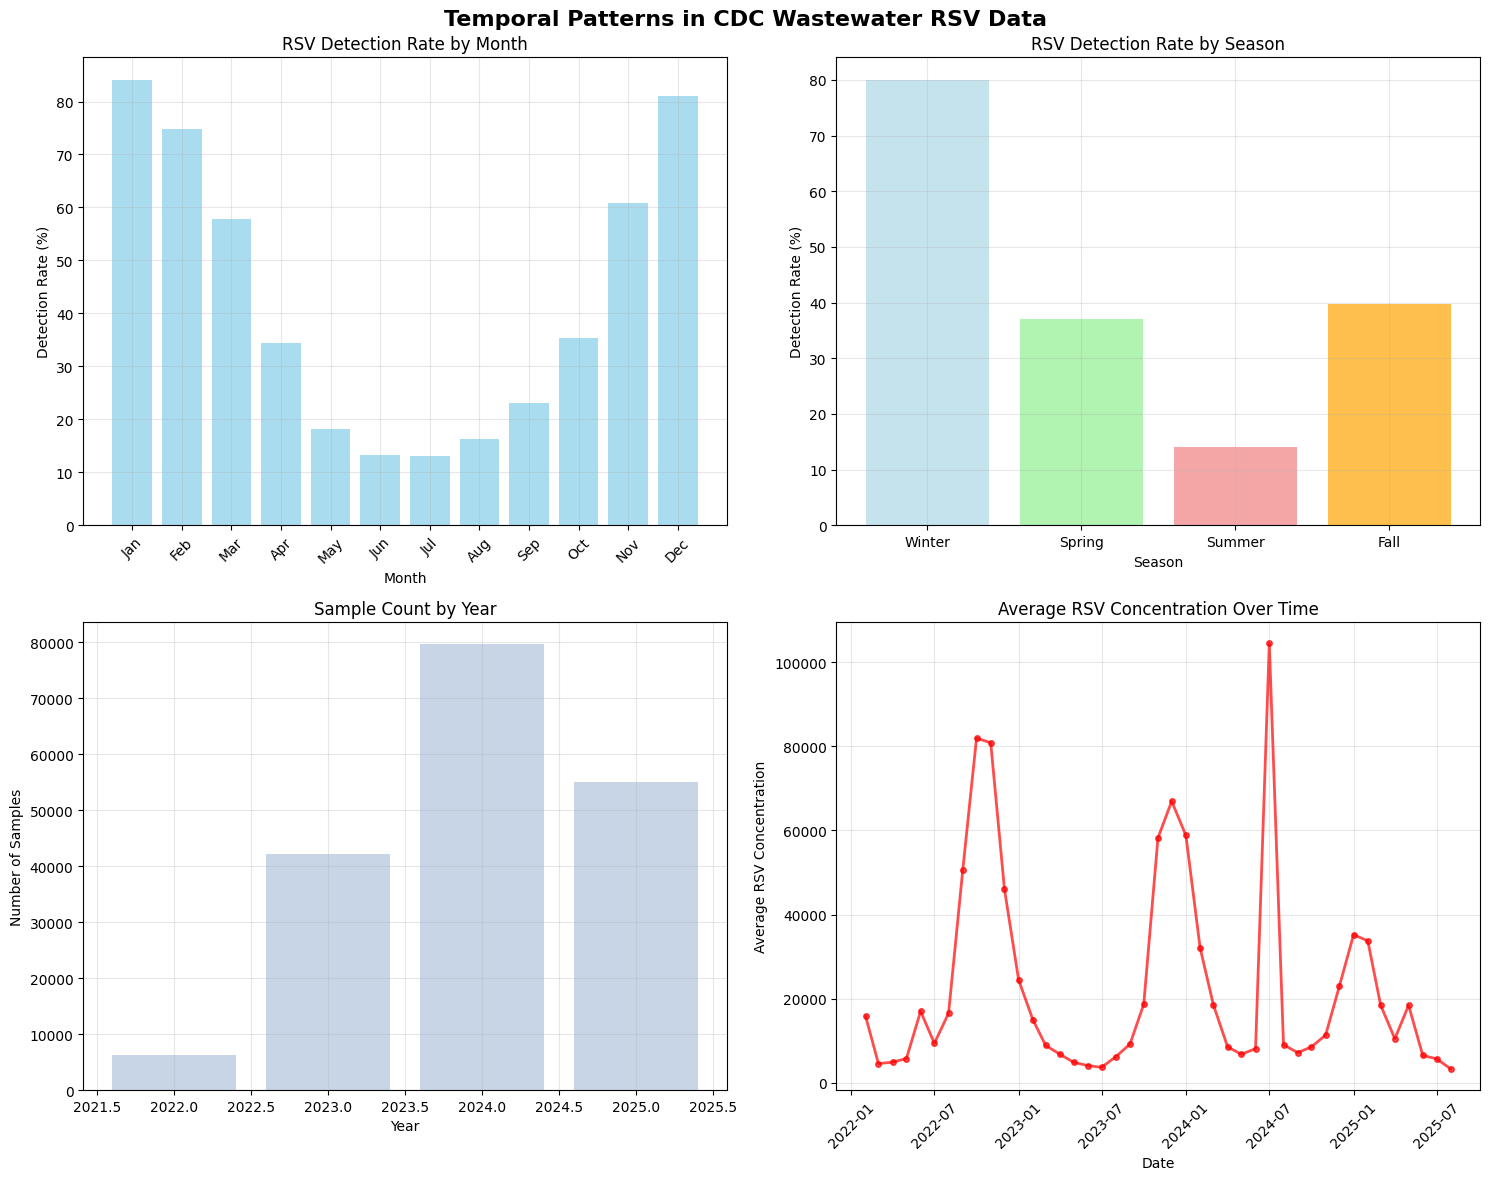

✅ Temporal visualizations saved as 'temporal_patterns.png'

=== PROCESSING COMPLETED ===
✅ Processed dataset saved as: cdc_wastewater_temporal_processed.csv
📊 New temporal features added:
   - year: Year of sample collection
   - month: Month (1-12)
   - month_name: Month name (January, February, etc.)
   - epi_week: Epidemiological week (1-53)
   - epi_year: Epidemiological year
   - epi_week_id: Epi-week identifier (YYYY-WW format)
   - day_of_week: Day of week (0=Monday, 6=Sunday)
   - day_name: Day name (Monday, Tuesday, etc.)
   - quarter: Quarter (1-4)
   - day_of_year: Day of year (1-366)
   - season: Season (Winter, Spring, Summer, Fall)

🎯 Ready for temporal RSV analysis!
Dataset shape: (183146, 45)
Date range: 2022-02-27 00:00:00 to 2025-08-12 00:00:00


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta


def convert_date_and_derive_features(df):
    """
    Convert sample_collect_date to datetime and derive year, month, epi-week
    """
    print("=== DATE PROCESSING ===")

    # Make a copy to avoid modifying original
    df_processed = df.copy()

    # Check current date format
    print(f"Original sample_collect_date format:")
    print(f"First few values: {df_processed['sample_collect_date'].head()}")
    print(f"Data type: {df_processed['sample_collect_date'].dtype}")

    # Convert to datetime
    print(f"\nConverting sample_collect_date to datetime...")
    df_processed['sample_collect_date'] = pd.to_datetime(df_processed['sample_collect_date'])

    print(f"✅ Date conversion completed!")
    print(f"New data type: {df_processed['sample_collect_date'].dtype}")
    print(f"Date range: {df_processed['sample_collect_date'].min()} to {df_processed['sample_collect_date'].max()}")

    # Derive year
    print(f"\nDeriving year...")
    df_processed['year'] = df_processed['sample_collect_date'].dt.year

    # Derive month
    print(f"Deriving month...")
    df_processed['month'] = df_processed['sample_collect_date'].dt.month
    df_processed['month_name'] = df_processed['sample_collect_date'].dt.strftime('%B')

    # Derive epi-week (epidemiological week)
    print(f"Deriving epidemiological week...")
    df_processed['epi_week'] = df_processed['sample_collect_date'].dt.isocalendar().week
    df_processed['epi_year'] = df_processed['sample_collect_date'].dt.isocalendar().year

    # Create epi-week identifier (YYYY-WW format)
    df_processed['epi_week_id'] = df_processed['epi_year'].astype(str) + '-W' + df_processed['epi_week'].astype(str).str.zfill(2)

    # Derive additional time features
    print(f"Deriving additional time features...")
    df_processed['day_of_week'] = df_processed['sample_collect_date'].dt.dayofweek
    df_processed['day_name'] = df_processed['sample_collect_date'].dt.strftime('%A')
    df_processed['quarter'] = df_processed['sample_collect_date'].dt.quarter
    df_processed['day_of_year'] = df_processed['sample_collect_date'].dt.dayofyear

    # Create season feature
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'

    df_processed['season'] = df_processed['month'].apply(get_season)

    print(f"✅ All date features derived successfully!")

    return df_processed

def analyze_temporal_patterns(df):
    """
    Analyze temporal patterns in the data
    """
    print("\n=== TEMPORAL PATTERN ANALYSIS ===")

    # Year analysis
    print(f"\nYear Distribution:")
    year_counts = df['year'].value_counts().sort_index()
    for year, count in year_counts.items():
        print(f"  {year}: {count:,} samples ({count/len(df)*100:.1f}%)")

    # Month analysis
    print(f"\nMonth Distribution:")
    month_counts = df['month'].value_counts().sort_index()
    for month, count in month_counts.items():
        month_name = df[df['month'] == month]['month_name'].iloc[0]
        print(f"  {month_name}: {count:,} samples ({count/len(df)*100:.1f}%)")

    # Season analysis
    print(f"\nSeason Distribution:")
    season_counts = df['season'].value_counts()
    for season, count in season_counts.items():
        print(f"  {season}: {count:,} samples ({count/len(df)*100:.1f}%)")

    # Epi-week analysis
    print(f"\nEpidemiological Week Analysis:")
    print(f"  Epi-weeks range: {df['epi_week'].min()} to {df['epi_week'].max()}")
    print(f"  Epi-years range: {df['epi_year'].min()} to {df['epi_year'].max()}")

    # RSV detection by month
    print(f"\nRSV Detection by Month:")
    rsv_by_month = df.groupby('month').agg({
        'pcr_target_avg_conc': ['count', lambda x: (x > 0).sum()]
    }).round(2)
    rsv_by_month.columns = ['Total_Samples', 'RSV_Positive']
    rsv_by_month['Detection_Rate'] = (rsv_by_month['RSV_Positive'] / rsv_by_month['Total_Samples'] * 100).round(2)

    for month in range(1, 13):
        if month in rsv_by_month.index:
            month_name = df[df['month'] == month]['month_name'].iloc[0]
            total = rsv_by_month.loc[month, 'Total_Samples']
            positive = rsv_by_month.loc[month, 'RSV_Positive']
            rate = rsv_by_month.loc[month, 'Detection_Rate']
            print(f"  {month_name}: {positive:,}/{total:,} ({rate:.1f}%)")

    # RSV detection by season
    print(f"\nRSV Detection by Season:")
    rsv_by_season = df.groupby('season').agg({
        'pcr_target_avg_conc': ['count', lambda x: (x > 0).sum()]
    }).round(2)
    rsv_by_season.columns = ['Total_Samples', 'RSV_Positive']
    rsv_by_season['Detection_Rate'] = (rsv_by_season['RSV_Positive'] / rsv_by_season['Total_Samples'] * 100).round(2)

    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        if season in rsv_by_season.index:
            total = rsv_by_season.loc[season, 'Total_Samples']
            positive = rsv_by_season.loc[season, 'RSV_Positive']
            rate = rsv_by_season.loc[season, 'Detection_Rate']
            print(f"  {season}: {positive:,}/{total:,} ({rate:.1f}%)")

def create_temporal_visualizations(df):
    """
    Create visualizations for temporal patterns
    """
    print("\n=== CREATING TEMPORAL VISUALIZATIONS ===")

    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Temporal Patterns in CDC Wastewater RSV Data', fontsize=16, fontweight='bold')

    # 1. RSV Detection by Month
    rsv_by_month = df.groupby('month').agg({
        'pcr_target_avg_conc': ['count', lambda x: (x > 0).sum()]
    })
    rsv_by_month.columns = ['Total', 'Positive']
    rsv_by_month['Rate'] = rsv_by_month['Positive'] / rsv_by_month['Total'] * 100

    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    axes[0, 0].bar(rsv_by_month.index, rsv_by_month['Rate'], color='skyblue', alpha=0.7)
    axes[0, 0].set_title('RSV Detection Rate by Month')
    axes[0, 0].set_xlabel('Month')
    axes[0, 0].set_ylabel('Detection Rate (%)')
    axes[0, 0].set_xticks(range(1, 13))
    axes[0, 0].set_xticklabels(month_names, rotation=45)
    axes[0, 0].grid(True, alpha=0.3)

    # 2. RSV Detection by Season
    rsv_by_season = df.groupby('season').agg({
        'pcr_target_avg_conc': ['count', lambda x: (x > 0).sum()]
    })
    rsv_by_season.columns = ['Total', 'Positive']
    rsv_by_season['Rate'] = rsv_by_season['Positive'] / rsv_by_season['Total'] * 100

    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    season_rates = [rsv_by_season.loc[season, 'Rate'] for season in season_order]

    colors = ['lightblue', 'lightgreen', 'lightcoral', 'orange']
    axes[0, 1].bar(season_order, season_rates, color=colors, alpha=0.7)
    axes[0, 1].set_title('RSV Detection Rate by Season')
    axes[0, 1].set_xlabel('Season')
    axes[0, 1].set_ylabel('Detection Rate (%)')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Sample Count by Year
    year_counts = df['year'].value_counts().sort_index()
    axes[1, 0].bar(year_counts.index, year_counts.values, color='lightsteelblue', alpha=0.7)
    axes[1, 0].set_title('Sample Count by Year')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Number of Samples')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. RSV Concentration Over Time (monthly average)
    monthly_rsv = df[df['pcr_target_avg_conc'] > 0].groupby(['year', 'month'])['pcr_target_avg_conc'].mean().reset_index()
    monthly_rsv['date'] = pd.to_datetime(monthly_rsv[['year', 'month']].assign(day=1))

    axes[1, 1].plot(monthly_rsv['date'], monthly_rsv['pcr_target_avg_conc'],
                    marker='o', linewidth=2, markersize=4, color='red', alpha=0.7)
    axes[1, 1].set_title('Average RSV Concentration Over Time')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Average RSV Concentration')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Temporal visualizations saved as 'temporal_patterns.png'")

def main():
    """
    Main function to process dates and derive temporal features
    """
    # Load the hybrid dataset
    print("Loading hybrid dataset...")
    df = load_hybrid_dataset()

    if df is None:
        print("Failed to load dataset")
        return

    # Process dates and derive features
    df_processed = convert_date_and_derive_features(df)

    # Analyze temporal patterns
    analyze_temporal_patterns(df_processed)

    # Create visualizations
    create_temporal_visualizations(df_processed)

    # Save the processed dataset
    output_file = 'cdc_wastewater_temporal_processed.csv'
    df_processed.to_csv(output_file, index=False)

    print(f"\n=== PROCESSING COMPLETED ===")
    print(f"✅ Processed dataset saved as: {output_file}")
    print(f"📊 New temporal features added:")
    print(f"   - year: Year of sample collection")
    print(f"   - month: Month (1-12)")
    print(f"   - month_name: Month name (January, February, etc.)")
    print(f"   - epi_week: Epidemiological week (1-53)")
    print(f"   - epi_year: Epidemiological year")
    print(f"   - epi_week_id: Epi-week identifier (YYYY-WW format)")
    print(f"   - day_of_week: Day of week (0=Monday, 6=Sunday)")
    print(f"   - day_name: Day name (Monday, Tuesday, etc.)")
    print(f"   - quarter: Quarter (1-4)")
    print(f"   - day_of_year: Day of year (1-366)")
    print(f"   - season: Season (Winter, Spring, Summer, Fall)")

    print(f"\n🎯 Ready for temporal RSV analysis!")
    print(f"Dataset shape: {df_processed.shape}")
    print(f"Date range: {df_processed['sample_collect_date'].min()} to {df_processed['sample_collect_date'].max()}")

if __name__ == "__main__":
    main()

Loading temporal dataset...
✅ Loaded temporal dataset: (44543, 45)
=== CATEGORICAL COLUMNS ANALYSIS ===
Found 26 categorical columns:
  wwtp_jurisdiction: 51 unique values
  county_fips: 711 unique values
  counties_served: 574 unique values
  sample_id: 44542 unique values
  sample_collect_date: 1188 unique values
  sample_type: 16 unique values
  sample_matrix: 4 unique values
  sample_location: 2 unique values
  concentration_method: 14 unique values
  pasteurized: 2 unique values
  pcr_type: 6 unique values
  extraction_method: 21 unique values
  inhibition_detect: 3 unique values
  ntc_amplify: 1 unique values
  pcr_target: 1 unique values
  pcr_gene_target_agg: 5 unique values
  pcr_target_units: 2 unique values
  hum_frac_target_mic: 5 unique values
  hum_frac_mic_unit: 2 unique values
  rec_eff_target_name: 9 unique values
  rec_eff_spike_matrix: 6 unique values
  date_updated: 1 unique values
  month_name: 12 unique values
  epi_week_id: 181 unique values
  day_name: 7 unique 

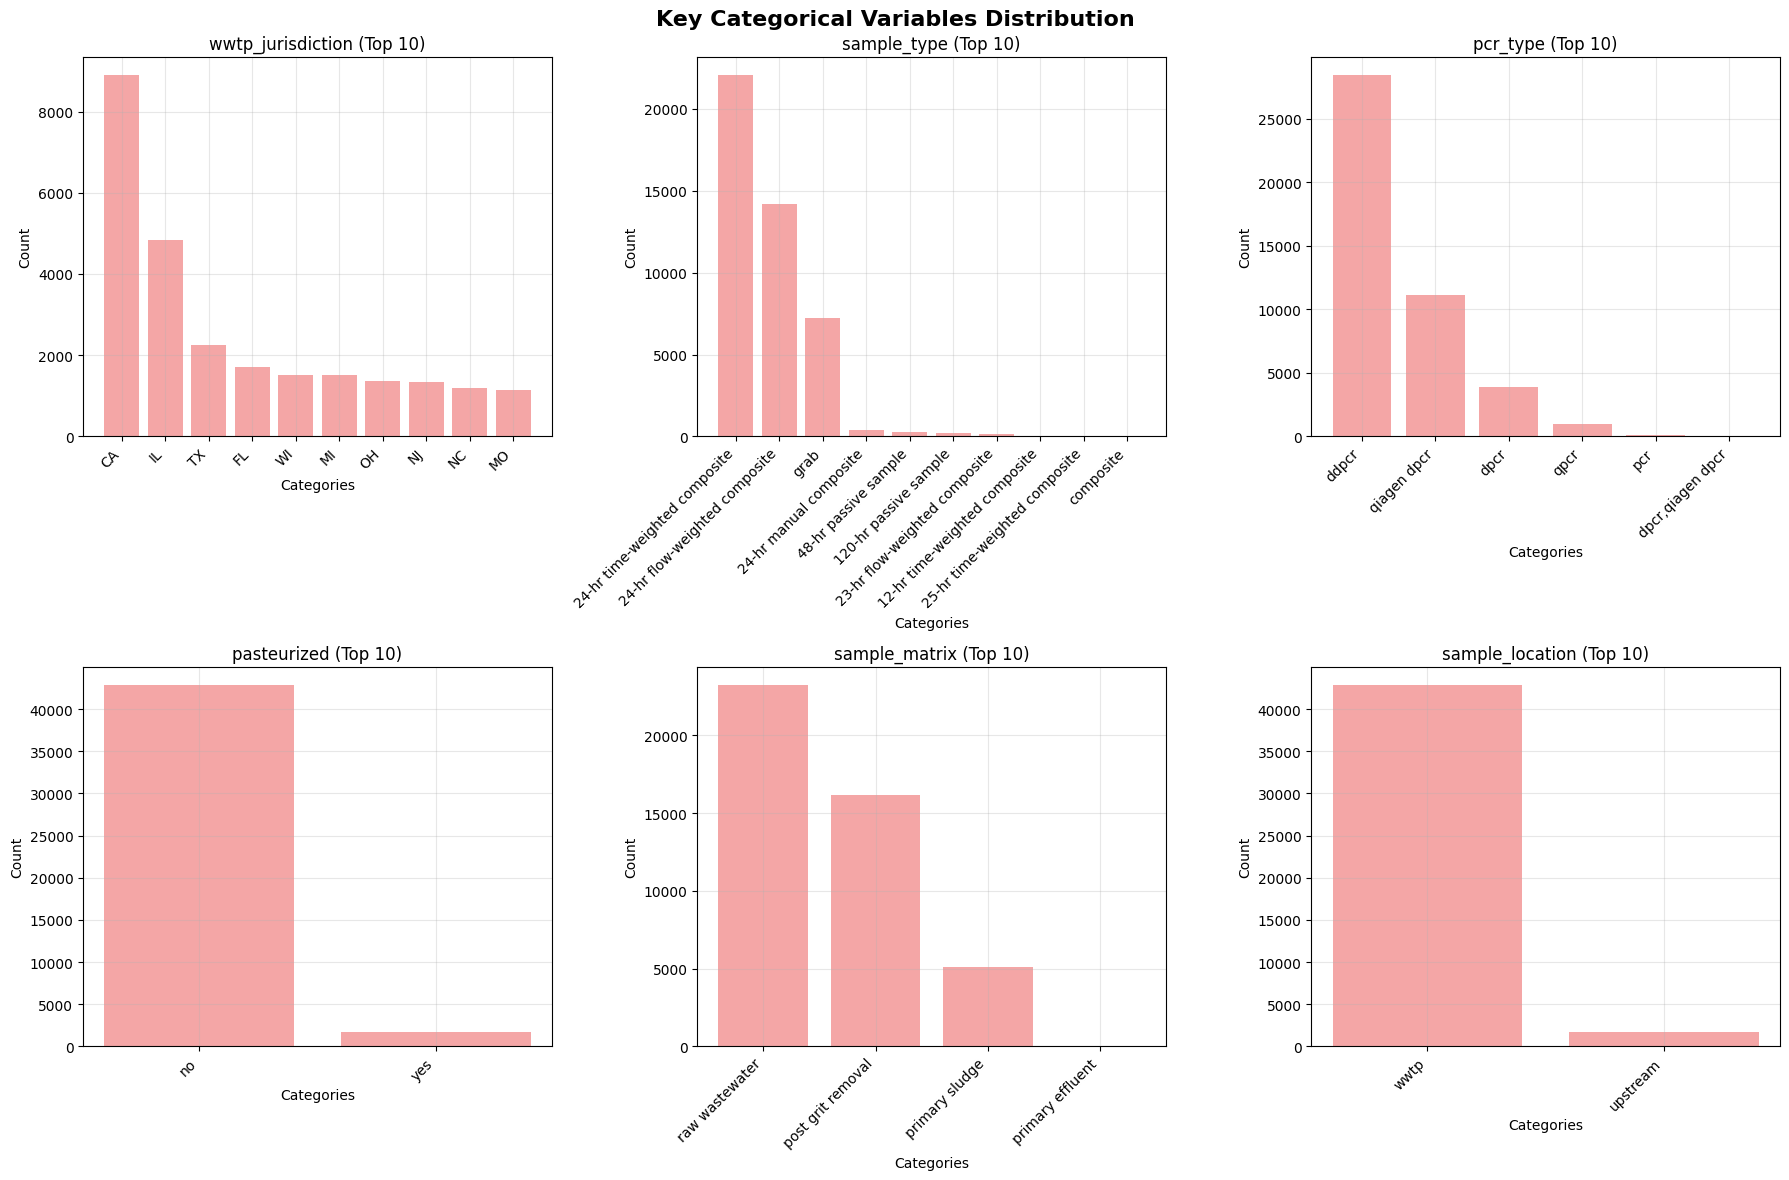

✅ Categorical visualizations saved as 'categorical_distributions.png'

=== CATEGORICAL STANDARDIZATION COMPLETED ===
✅ Processed datasets saved:
   1. cdc_wastewater_categorical_standardized.csv - Standardized values
   2. cdc_wastewater_label_encoded.csv - Label encoding applied
   3. cdc_wastewater_target_encoded.csv - Target encoding applied
   4. cdc_wastewater_freq_encoded.csv - Frequency encoding applied
   5. cdc_wastewater_ml_ready.csv - ML-ready dataset (RECOMMENDED)

📊 Summary:
   - Original categorical columns: 26
   - Standardized values for consistency
   - Multiple encoding strategies available
   - Memory-efficient processing

🎯 Recommendation:
   - Use 'cdc_wastewater_ml_ready.csv' for machine learning
   - Contains optimal mix of original and encoded features
   - Target encoding for high cardinality variables
   - Removed non-useful columns


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


def analyze_categorical_columns(df):
    """
    Analyze categorical columns in the dataset
    """
    print("=== CATEGORICAL COLUMNS ANALYSIS ===")

    # Identify categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
    print(f"Found {len(categorical_columns)} categorical columns:")

    categorical_analysis = {}

    for col in categorical_columns:
        unique_count = df[col].nunique()
        print(f"  {col}: {unique_count} unique values")

        # Categorize by cardinality
        if unique_count <= 10:
            cardinality = "Low"
        elif unique_count <= 50:
            cardinality = "Medium"
        else:
            cardinality = "High"

        categorical_analysis[col] = {
            'unique_count': unique_count,
            'cardinality': cardinality
        }

    return categorical_columns, categorical_analysis

def standardize_categorical_values(df):
    """
    Standardize categorical values efficiently
    """
    print("\n=== CATEGORICAL STANDARDIZATION ===")

    df_standardized = df.copy()
    categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

    # Remove temporal columns that were added
    temporal_columns = ['month_name', 'day_name', 'season', 'epi_week_id']
    original_categoricals = [col for col in categorical_columns if col not in temporal_columns]

    print(f"Standardizing {len(original_categoricals)} original categorical columns:")

    for col in original_categoricals:
        print(f"\nProcessing: {col}")

        # 1. Convert to string and strip whitespace
        df_standardized[col] = df_standardized[col].astype(str).str.strip()

        # 2. Standardize case based on column type
        if col in ['wwtp_jurisdiction', 'county_fips']:
            # Keep codes as is
            pass
        elif col in ['sample_type', 'sample_matrix', 'sample_location', 'concentration_method',
                     'pasteurized', 'pcr_type', 'extraction_method', 'major_lab_method',
                     'inhibition_detect', 'ntc_amplify', 'pcr_target_units', 'hum_frac_target_mic',
                     'hum_frac_mic_unit', 'rec_eff_target_name', 'rec_eff_spike_matrix']:
            # Convert to lowercase for consistency
            df_standardized[col] = df_standardized[col].str.lower()
        else:
            # Title case for other fields
            df_standardized[col] = df_standardized[col].str.title()

        # 3. Handle special cases
        if col == 'wwtp_jurisdiction':
            # Ensure state codes are uppercase
            df_standardized[col] = df_standardized[col].str.upper()

        # 4. Show before/after comparison
        before_unique = df[col].nunique()
        after_unique = df_standardized[col].nunique()
        print(f"  Unique values: {before_unique} → {after_unique}")

        if before_unique != after_unique:
            print(f"  ✅ Reduced unique values through standardization")

    return df_standardized

def create_efficient_encoding(df):
    """
    Create efficient encoding strategies for categorical variables
    """
    print("\n=== EFFICIENT ENCODING STRATEGIES ===")

    categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
    temporal_columns = ['month_name', 'day_name', 'season', 'epi_week_id']
    original_categoricals = [col for col in categorical_columns if col not in temporal_columns]

    # Strategy 1: Label Encoding for all categorical variables
    print(f"\n1. Label Encoding Strategy (Recommended for tree-based models):")
    label_encoders = {}
    df_label_encoded = df.copy()

    for col in original_categoricals:
        le = LabelEncoder()
        df_label_encoded[f'{col}_encoded'] = le.fit_transform(df[col])
        label_encoders[col] = le
        print(f"  ✅ Encoded {col} ({df[col].nunique()} unique values)")

    # Strategy 2: Target Encoding for high cardinality variables
    print(f"\n2. Target Encoding Strategy (for high cardinality):")
    df_target_encoded = df.copy()

    if 'pcr_target_avg_conc' in df.columns:
        # Create binary target (RSV detected or not)
        target = (df['pcr_target_avg_conc'] > 0).astype(int)

        # Apply target encoding to high cardinality columns only
        high_cardinality_cols = ['wwtp_jurisdiction', 'county_fips', 'counties_served']

        for col in high_cardinality_cols:
            if col in df.columns:
                # Calculate target encoding
                target_means = df.groupby(col)['pcr_target_avg_conc'].apply(lambda x: (x > 0).mean())
                df_target_encoded[f'{col}_target_encoded'] = df[col].map(target_means)

                # Fill missing values with global mean
                global_mean = target.mean()
                df_target_encoded[f'{col}_target_encoded'].fillna(global_mean, inplace=True)

                print(f"  ✅ Target encoded {col} (RSV detection rate)")

    # Strategy 3: Frequency encoding for high cardinality
    print(f"\n3. Frequency Encoding Strategy:")
    df_freq_encoded = df.copy()

    high_cardinality_cols = ['wwtp_jurisdiction', 'county_fips', 'counties_served']
    for col in high_cardinality_cols:
        if col in df.columns:
            # Calculate frequency of each category
            freq_encoding = df[col].value_counts(normalize=True)
            df_freq_encoded[f'{col}_freq_encoded'] = df[col].map(freq_encoding)

            # Fill missing values with 0
            df_freq_encoded[f'{col}_freq_encoded'].fillna(0, inplace=True)

            print(f"  ✅ Frequency encoded {col}")

    return df_label_encoded, df_target_encoded, df_freq_encoded, label_encoders

def create_ml_ready_dataset(df, label_encoders):
    """
    Create a machine learning ready dataset with optimal encoding
    """
    print("\n=== CREATING ML-READY DATASET ===")

    df_ml = df.copy()

    # 1. Keep original categorical columns for reference
    # 2. Add label encoded versions for tree-based models
    # 3. Add target encoded versions for high cardinality
    # 4. Remove problematic columns

    # Remove columns that are not useful for ML
    columns_to_remove = [
        'sample_id',  # Unique identifier, not useful for ML
        'date_updated',  # Single value, not useful
        'ntc_amplify',  # Single value
        'pcr_target',  # Single value (all RSV)
        'sample_collect_date'  # Already converted to temporal features
    ]

    for col in columns_to_remove:
        if col in df_ml.columns:
            df_ml = df_ml.drop(columns=[col])
            print(f"  Removed {col} (not useful for ML)")

    # Add target encoding for high cardinality
    if 'pcr_target_avg_conc' in df_ml.columns:
        high_cardinality_cols = ['wwtp_jurisdiction', 'county_fips', 'counties_served']
        for col in high_cardinality_cols:
            if col in df_ml.columns:
                target_means = df_ml.groupby(col)['pcr_target_avg_conc'].apply(lambda x: (x > 0).mean())
                df_ml[f'{col}_rsv_rate'] = df_ml[col].map(target_means)
                df_ml[f'{col}_rsv_rate'].fillna(0.5, inplace=True)  # Default to 50% if no data
                print(f"  Added {col}_rsv_rate (target encoding)")

    return df_ml

def analyze_encoding_impact(df, df_encoded, label_encoders):
    """
    Analyze the impact of encoding on the dataset
    """
    print("\n=== ENCODING IMPACT ANALYSIS ===")

    original_shape = df.shape
    encoded_shape = df_encoded.shape

    print(f"Dataset shape: {original_shape} → {encoded_shape}")
    print(f"Additional columns: {encoded_shape[1] - original_shape[1]}")

    # Show encoding mappings for key columns
    key_columns = ['wwtp_jurisdiction', 'sample_type', 'pcr_type', 'pasteurized']
    print(f"\nLabel Encoding Mappings (key columns):")
    for col in key_columns:
        if col in label_encoders:
            print(f"\n{col}:")
            for i, label in enumerate(label_encoders[col].classes_[:10]):  # Show first 10
                print(f"  {i}: '{label}'")
            if len(label_encoders[col].classes_) > 10:
                print(f"  ... and {len(label_encoders[col].classes_) - 10} more")

def create_categorical_visualizations(df):
    """
    Create visualizations for key categorical variables
    """
    print("\n=== CREATING CATEGORICAL VISUALIZATIONS ===")

    # Select key categorical columns for visualization
    key_categoricals = ['wwtp_jurisdiction', 'sample_type', 'pcr_type', 'pasteurized', 'sample_matrix', 'sample_location']

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Key Categorical Variables Distribution', fontsize=16, fontweight='bold')

    for i, col in enumerate(key_categoricals):
        if col in df.columns:
            row = i // 3
            col_idx = i % 3

            # Get top 10 values
            value_counts = df[col].value_counts().head(10)

            axes[row, col_idx].bar(range(len(value_counts)), value_counts.values, color='lightcoral', alpha=0.7)
            axes[row, col_idx].set_title(f'{col} (Top 10)', fontsize=12)
            axes[row, col_idx].set_xlabel('Categories')
            axes[row, col_idx].set_ylabel('Count')
            axes[row, col_idx].set_xticks(range(len(value_counts)))
            axes[row, col_idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[row, col_idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('categorical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Categorical visualizations saved as 'categorical_distributions.png'")

def main():
    """
    Main function to standardize categorical fields efficiently
    """
    # Load the temporal dataset
    print("Loading temporal dataset...")
    try:
        df = pd.read_csv('cdc_wastewater_temporal_processed.csv')
        print(f"✅ Loaded temporal dataset: {df.shape}")
    except FileNotFoundError:
        print("❌ Temporal dataset not found. Loading hybrid dataset...")
        df = load_hybrid_dataset()
        if df is None:
            print("❌ Failed to load dataset")
            return

    # Analyze categorical columns
    categorical_columns, categorical_analysis = analyze_categorical_columns(df)

    # Standardize categorical values
    df_standardized = standardize_categorical_values(df)

    # Create efficient encoding strategies
    df_label_encoded, df_target_encoded, df_freq_encoded, label_encoders = create_efficient_encoding(df_standardized)

    # Create ML-ready dataset
    df_ml_ready = create_ml_ready_dataset(df_standardized, label_encoders)

    # Analyze encoding impact
    analyze_encoding_impact(df_standardized, df_label_encoded, label_encoders)

    # Create visualizations
    create_categorical_visualizations(df_standardized)

    # Save processed datasets
    df_standardized.to_csv('cdc_wastewater_categorical_standardized.csv', index=False)
    df_label_encoded.to_csv('cdc_wastewater_label_encoded.csv', index=False)
    df_target_encoded.to_csv('cdc_wastewater_target_encoded.csv', index=False)
    df_freq_encoded.to_csv('cdc_wastewater_freq_encoded.csv', index=False)
    df_ml_ready.to_csv('cdc_wastewater_ml_ready.csv', index=False)

    print(f"\n=== CATEGORICAL STANDARDIZATION COMPLETED ===")
    print(f"✅ Processed datasets saved:")
    print(f"   1. cdc_wastewater_categorical_standardized.csv - Standardized values")
    print(f"   2. cdc_wastewater_label_encoded.csv - Label encoding applied")
    print(f"   3. cdc_wastewater_target_encoded.csv - Target encoding applied")
    print(f"   4. cdc_wastewater_freq_encoded.csv - Frequency encoding applied")
    print(f"   5. cdc_wastewater_ml_ready.csv - ML-ready dataset (RECOMMENDED)")

    print(f"\n📊 Summary:")
    print(f"   - Original categorical columns: {len(categorical_columns)}")
    print(f"   - Standardized values for consistency")
    print(f"   - Multiple encoding strategies available")
    print(f"   - Memory-efficient processing")

    print(f"\n🎯 Recommendation:")
    print(f"   - Use 'cdc_wastewater_ml_ready.csv' for machine learning")
    print(f"   - Contains optimal mix of original and encoded features")
    print(f"   - Target encoding for high cardinality variables")
    print(f"   - Removed non-useful columns")

if __name__ == "__main__":
    main()


           FINAL OUTLIER HANDLING PLAN
=== COMPREHENSIVE OUTLIER ANALYSIS ===
✅ Loaded dataset: (44543, 43)

📊 Analyzing 22 numerical columns for outliers

=== DETAILED OUTLIER ANALYSIS ===

🔍 Analyzing: sewershed_id
   - Mean: 940.36
   - Median: 639.00
   - Std: 756.40
   - Min: 2.00
   - Max: 2,573.00
   - IQR Outliers: 0 (0.00%)
   - Z-score Outliers: 0 (0.00%)

🔍 Analyzing: population_served
   - Mean: 206,315.48
   - Median: 60,000.00
   - Std: 480,826.78
   - Min: 564.00
   - Max: 4,000,000.00
   - IQR Outliers: 5,434 (12.20%)
   - Z-score Outliers: 921 (2.07%)

🔍 Analyzing: flow_rate
   - Mean: 14.14
   - Median: 5.00
   - Std: 39.91
   - Min: 0.00
   - Max: 1,440.00
   - IQR Outliers: 7,543 (16.93%)
   - Z-score Outliers: 870 (1.95%)

🔍 Analyzing: major_lab_method
   - Mean: 5.05
   - Median: 1.00
   - Std: 41.14
   - Min: 0.00
   - Max: 999.00
   - IQR Outliers: 4,841 (10.87%)
   - Z-score Outliers: 73 (0.16%)

🔍 Analyzing: pcr_target_avg_conc
   - Mean: 11,530.99
   - Media

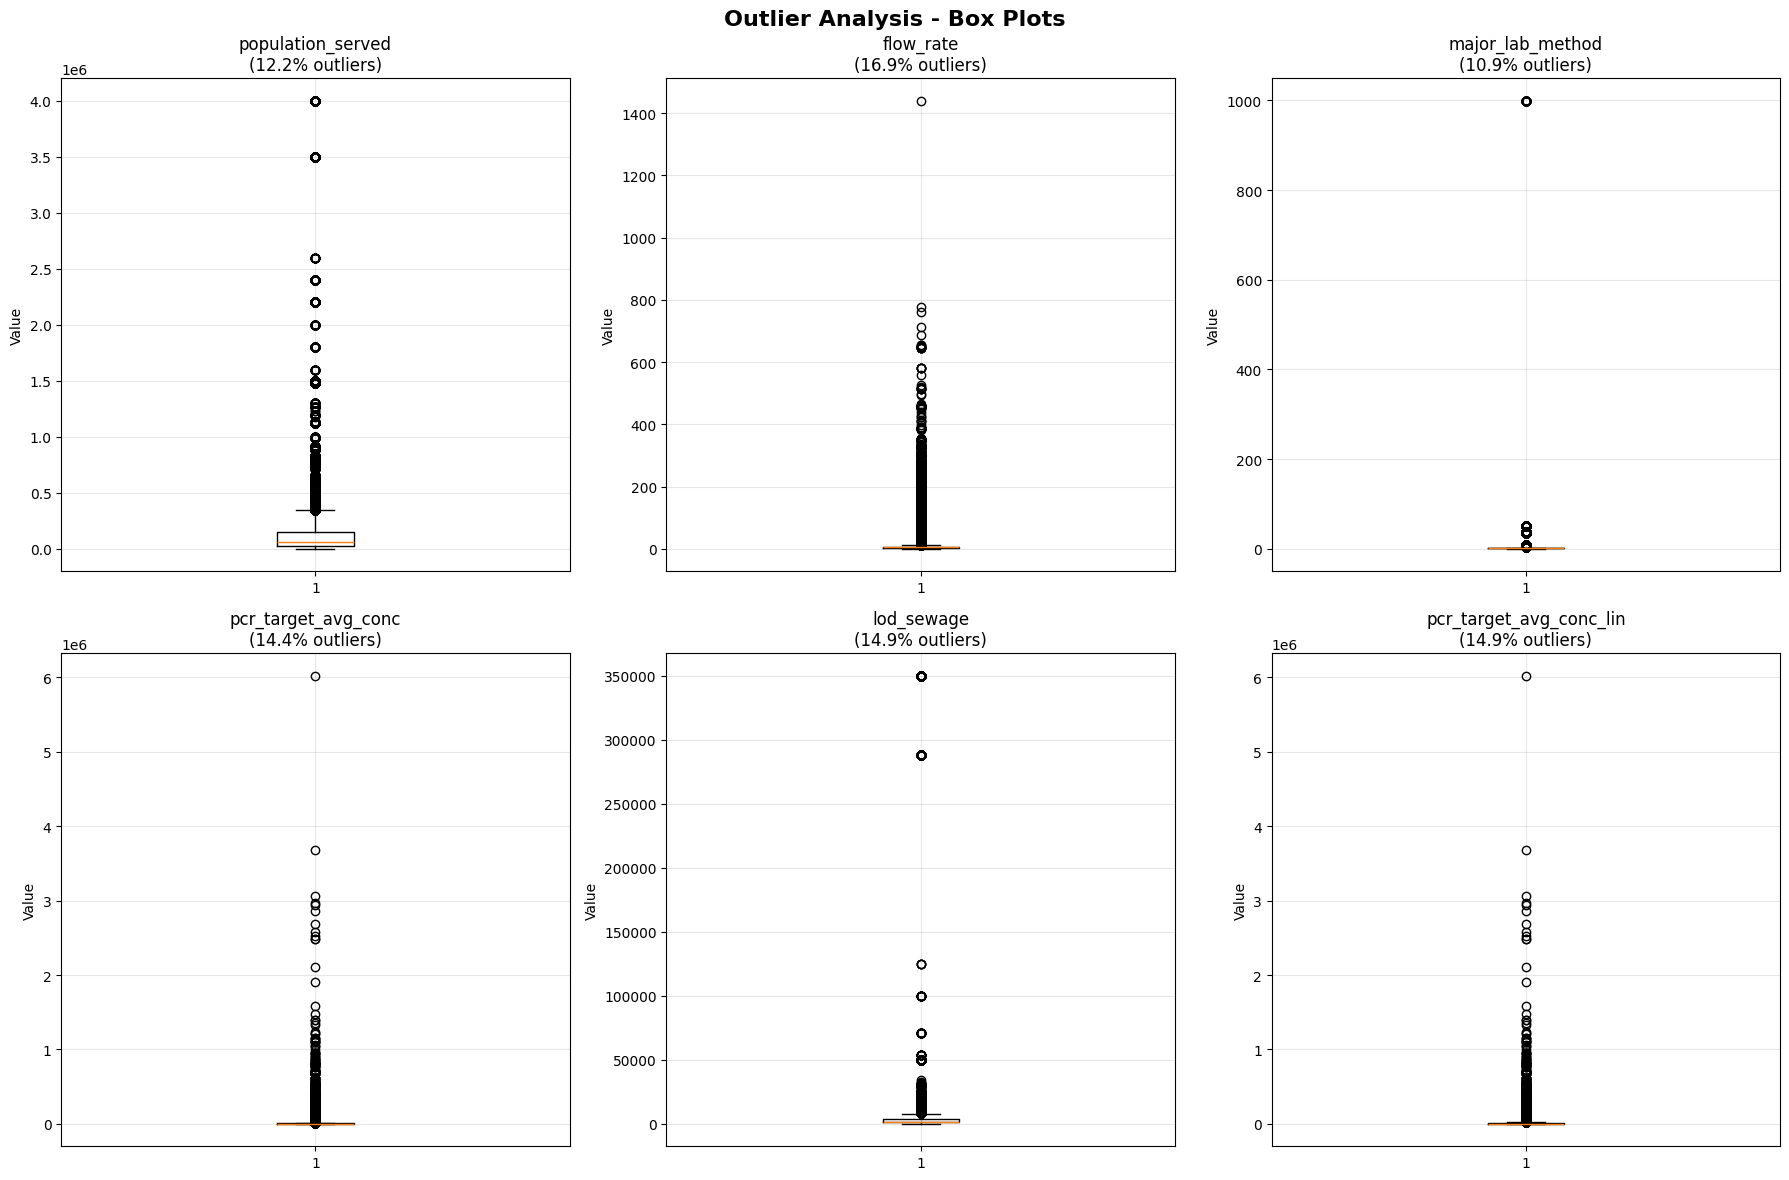

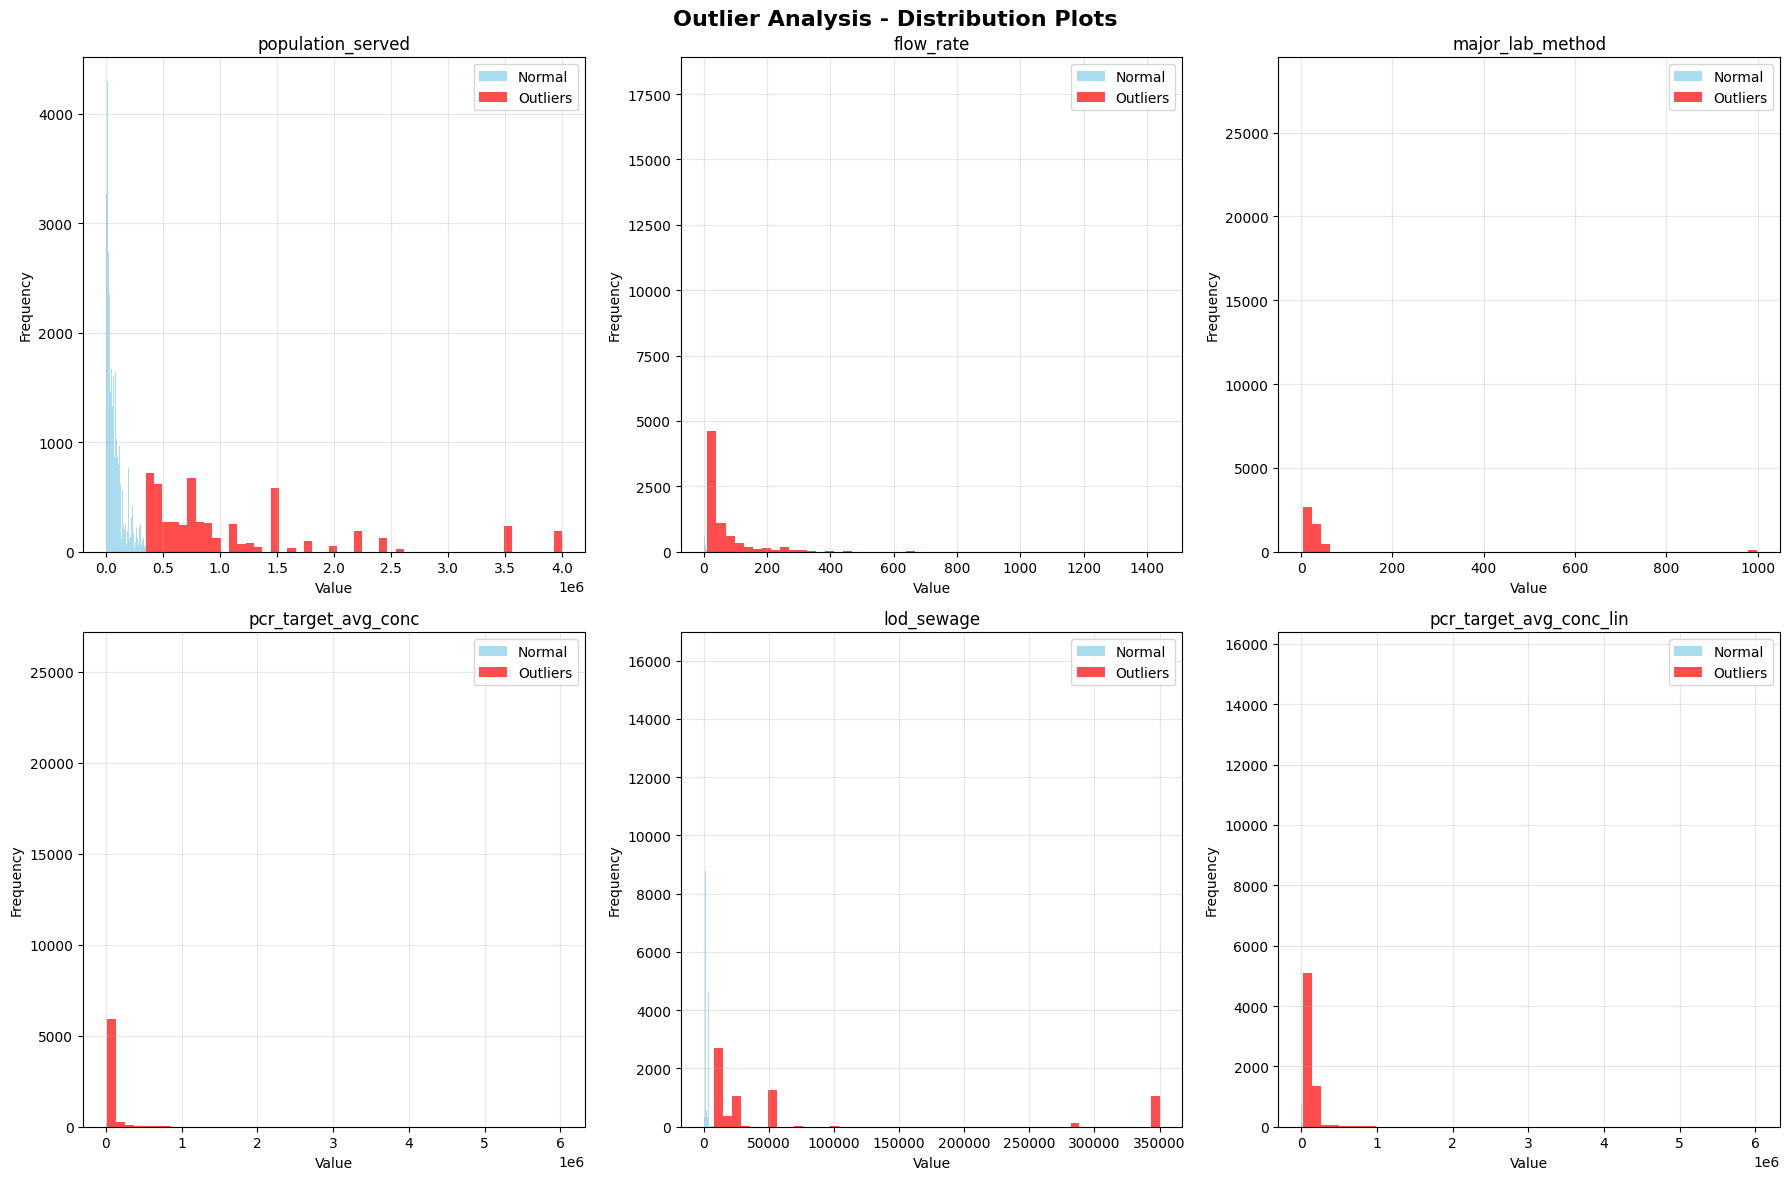

✅ Outlier visualizations saved as 'outlier_boxplots.png' and 'outlier_distributions.png'

=== OUTLIER HANDLING STRATEGIES ===
🎯 Demonstrating strategies using column: population_served
   - Original data shape: 44543
   - Original mean: 206315.48
   - Original std: 480826.78

1️⃣ STRATEGY 1: OUTLIER REMOVAL
   - After removal: 39109 records (removed 5434 outliers)
   - New mean: 75642.99
   - New std: 75287.38
   ✅ Pros: Clean data, no outliers
   ❌ Cons: Loss of data, potential information loss

2️⃣ STRATEGY 2: WINSORIZATION (CAPPING)
   - Winsorized mean: 109017.08
   - Winsorized std: 113987.73
   ✅ Pros: Preserves data size, reduces outlier impact
   ❌ Cons: May distort distribution, loses extreme values

3️⃣ STRATEGY 3: LOG TRANSFORMATION
   - Log-transformed mean: 11.05
   - Log-transformed std: 1.49
   ✅ Pros: Reduces skewness, handles right-skewed data
   ❌ Cons: Changes scale, may not work for all distributions

4️⃣ STRATEGY 4: ROBUST SCALING
   - Robust scaled mean: 3.18
   -

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def load_and_analyze_outliers():
    """
    Load the ML-ready dataset and perform comprehensive outlier analysis
    """
    print("=== COMPREHENSIVE OUTLIER ANALYSIS ===")

    # Load the dataset
    df = pd.read_csv('cdc_wastewater_ml_ready.csv')
    print(f"✅ Loaded dataset: {df.shape}")

    # Focus on numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\n📊 Analyzing {len(numerical_cols)} numerical columns for outliers")

    return df, numerical_cols

def detect_outliers_iqr(df, column):
    """
    Detect outliers using IQR method
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df)) * 100

    return {
        'outlier_count': outlier_count,
        'outlier_percent': outlier_percent,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR
    }

def detect_outliers_zscore(df, column, threshold=3):
    """
    Detect outliers using Z-score method
    """
    # Calculate Z-scores on the entire column
    z_scores = np.abs(stats.zscore(df[column]))
    # Select outliers where Z-score is not NaN and is above the threshold
    # Use numpy's isnan to check for NaN values
    outliers = df[~np.isnan(z_scores) & (z_scores > threshold)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df)) * 100

    return {
        'outlier_count': outlier_count,
        'outlier_percent': outlier_percent,
        'threshold': threshold
    }

def analyze_outliers_comprehensive(df, numerical_cols):
    """
    Perform comprehensive outlier analysis using multiple methods
    """
    print("\n=== DETAILED OUTLIER ANALYSIS ===")

    outlier_summary = {}

    for col in numerical_cols:
        print(f"\n🔍 Analyzing: {col}")

        # Basic statistics
        stats_info = df[col].describe()
        print(f"   - Mean: {stats_info['mean']:,.2f}")
        print(f"   - Median: {stats_info['50%']:,.2f}")
        print(f"   - Std: {stats_info['std']:,.2f}")
        print(f"   - Min: {stats_info['min']:,.2f}")
        print(f"   - Max: {stats_info['max']:,.2f}")

        # IQR method
        iqr_results = detect_outliers_iqr(df, col)
        print(f"   - IQR Outliers: {iqr_results['outlier_count']:,} ({iqr_results['outlier_percent']:.2f}%)")

        # Z-score method
        zscore_results = detect_outliers_zscore(df, col)
        print(f"   - Z-score Outliers: {zscore_results['outlier_count']:,} ({zscore_results['outlier_percent']:.2f}%)")

        outlier_summary[col] = {
            'iqr': iqr_results,
            'zscore': zscore_results,
            'basic_stats': stats_info
        }

    return outlier_summary

def create_outlier_visualizations(df, numerical_cols, outlier_summary):
    """
    Create comprehensive outlier visualizations
    """
    print("\n=== CREATING OUTLIER VISUALIZATIONS ===")

    # Select columns with significant outliers for visualization
    significant_outliers = []
    for col in numerical_cols:
        if outlier_summary[col]['iqr']['outlier_percent'] > 5:  # More than 5% outliers
            significant_outliers.append(col)

    print(f"📊 Creating visualizations for {len(significant_outliers)} columns with significant outliers")

    # Create box plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Outlier Analysis - Box Plots', fontsize=16, fontweight='bold')

    for i, col in enumerate(significant_outliers[:6]):  # Show first 6
        row = i // 3
        col_idx = i % 3

        # Create box plot
        axes[row, col_idx].boxplot(df[col].dropna(), vert=True)
        axes[row, col_idx].set_title(f'{col}\n({outlier_summary[col]["iqr"]["outlier_percent"]:.1f}% outliers)')
        axes[row, col_idx].set_ylabel('Value')
        axes[row, col_idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('outlier_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Create distribution plots with outlier highlighting
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Outlier Analysis - Distribution Plots', fontsize=16, fontweight='bold')

    for i, col in enumerate(significant_outliers[:6]):
        row = i // 3
        col_idx = i % 3

        # Get outlier bounds
        Q1 = outlier_summary[col]['iqr']['Q1']
        Q3 = outlier_summary[col]['iqr']['Q3']
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Create histogram with outlier highlighting
        data = df[col].dropna()
        normal_data = data[(data >= lower_bound) & (data <= upper_bound)]
        outlier_data = data[(data < lower_bound) | (data > upper_bound)]

        axes[row, col_idx].hist(normal_data, bins=50, alpha=0.7, color='skyblue', label='Normal')
        axes[row, col_idx].hist(outlier_data, bins=50, alpha=0.7, color='red', label='Outliers')
        axes[row, col_idx].set_title(f'{col}')
        axes[row, col_idx].set_xlabel('Value')
        axes[row, col_idx].set_ylabel('Frequency')
        axes[row, col_idx].legend()
        axes[row, col_idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('outlier_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Outlier visualizations saved as 'outlier_boxplots.png' and 'outlier_distributions.png'")

def demonstrate_outlier_handling_strategies(df, numerical_cols, outlier_summary):
    """
    Demonstrate different outlier handling strategies
    """
    print("\n=== OUTLIER HANDLING STRATEGIES ===")

    # Select a column with significant outliers for demonstration
    demo_col = None
    for col in numerical_cols:
        if outlier_summary[col]['iqr']['outlier_percent'] > 10:  # More than 10% outliers
            demo_col = col
            break

    if demo_col is None:
        demo_col = numerical_cols[0]  # Use first column if no significant outliers

    print(f"🎯 Demonstrating strategies using column: {demo_col}")

    # Get original data
    original_data = df[demo_col].dropna()
    print(f"   - Original data shape: {len(original_data)}")
    print(f"   - Original mean: {original_data.mean():.2f}")
    print(f"   - Original std: {original_data.std():.2f}")

    # Strategy 1: Removal
    print(f"\n1️⃣ STRATEGY 1: OUTLIER REMOVAL")
    Q1 = outlier_summary[demo_col]['iqr']['Q1']
    Q3 = outlier_summary[demo_col]['iqr']['Q3']
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data_removed = original_data[(original_data >= lower_bound) & (original_data <= upper_bound)]
    print(f"   - After removal: {len(data_removed)} records (removed {len(original_data) - len(data_removed)} outliers)")
    print(f"   - New mean: {data_removed.mean():.2f}")
    print(f"   - New std: {data_removed.std():.2f}")
    print(f"   ✅ Pros: Clean data, no outliers")
    print(f"   ❌ Cons: Loss of data, potential information loss")

    # Strategy 2: Winsorization (Capping)
    print(f"\n2️⃣ STRATEGY 2: WINSORIZATION (CAPPING)")
    data_winsorized = original_data.clip(lower=lower_bound, upper=upper_bound)
    print(f"   - Winsorized mean: {data_winsorized.mean():.2f}")
    print(f"   - Winsorized std: {data_winsorized.std():.2f}")
    print(f"   ✅ Pros: Preserves data size, reduces outlier impact")
    print(f"   ❌ Cons: May distort distribution, loses extreme values")

    # Strategy 3: Log Transformation
    print(f"\n3️⃣ STRATEGY 3: LOG TRANSFORMATION")
    data_log = np.log1p(original_data)  # log(1+x) to handle zeros
    print(f"   - Log-transformed mean: {data_log.mean():.2f}")
    print(f"   - Log-transformed std: {data_log.std():.2f}")
    print(f"   ✅ Pros: Reduces skewness, handles right-skewed data")
    print(f"   ❌ Cons: Changes scale, may not work for all distributions")

    # Strategy 4: Robust Scaling
    print(f"\n4️⃣ STRATEGY 4: ROBUST SCALING")
    median = original_data.median()
    mad = np.median(np.abs(original_data - median))  # Median Absolute Deviation
    data_robust = (original_data - median) / mad
    print(f"   - Robust scaled mean: {data_robust.mean():.2f}")
    print(f"   - Robust scaled std: {data_robust.std():.2f}")
    print(f"   ✅ Pros: Robust to outliers, preserves relative relationships")
    print(f"   ❌ Cons: Changes scale, may not be intuitive")

    # Strategy 5: Outlier Flagging
    print(f"\n5️⃣ STRATEGY 5: OUTLIER FLAGGING")
    outlier_flag = ((original_data < lower_bound) | (original_data > upper_bound)).astype(int)
    print(f"   - Outlier flag mean: {outlier_flag.mean():.2f} ({outlier_flag.mean()*100:.1f}% are outliers)")
    print(f"   ✅ Pros: Preserves all data, creates new feature")
    print(f"   ❌ Cons: Adds complexity, may not improve all models")

    return {
        'removal': data_removed,
        'winsorization': data_winsorized,
        'log_transform': data_log,
        'robust_scaling': data_robust,
        'outlier_flag': outlier_flag
    }

def create_outlier_strategy_comparison(df, numerical_cols, outlier_summary):
    """
    Create comparison of different outlier handling strategies
    """
    print("\n=== OUTLIER STRATEGY COMPARISON ===")

    comparison_data = []

    for col in numerical_cols:
        if outlier_summary[col]['iqr']['outlier_percent'] > 5:  # Only columns with significant outliers
            original_data = df[col].dropna()

            # Calculate statistics for each strategy
            Q1 = outlier_summary[col]['iqr']['Q1']
            Q3 = outlier_summary[col]['iqr']['Q3']
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Original
            original_mean = original_data.mean()
            original_std = original_data.std()

            # Removal
            data_removed = original_data[(original_data >= lower_bound) | (original_data > upper_bound)]
            removal_mean = data_removed.mean()
            removal_std = data_removed.std()

            # Winsorization
            data_winsorized = original_data.clip(lower=lower_bound, upper=upper_bound)
            winsorized_mean = data_winsorized.mean()
            winsorized_std = data_winsorized.std()

            comparison_data.append({
                'column': col,
                'outlier_percent': outlier_summary[col]['iqr']['outlier_percent'],
                'original_mean': original_mean,
                'original_std': original_std,
                'removal_mean': removal_mean,
                'removal_std': removal_std,
                'winsorized_mean': winsorized_mean,
                'winsorized_std': winsorized_std,
                'mean_change_removal': ((removal_mean - original_mean) / original_mean) * 100 if original_mean != 0 else None,
                'std_change_removal': ((removal_std - original_std) / original_std) * 100 if original_std != 0 else None,
                'mean_change_winsorized': ((winsorized_mean - original_mean) / original_mean) * 100 if original_mean != 0 else None,
                'std_change_winsorized': ((winsorized_std - original_std) / original_std) * 100 if original_std != 0 else None
            })


    comparison_df = pd.DataFrame(comparison_data)

    print(f"\n📊 Strategy Impact Summary:")
    print(f"   - Columns analyzed: {len(comparison_df)}")
    print(f"   - Average outlier percentage: {comparison_df['outlier_percent'].mean():.1f}%")
    print(f"   - Average mean change (removal): {comparison_df['mean_change_removal'].mean():.1f}%")
    print(f"   - Average std change (removal): {comparison_df['std_change_removal'].mean():.1f}%")
    print(f"   - Average mean change (winsorized): {comparison_df['mean_change_winsorized'].mean():.1f}%")
    print(f"   - Average std change (winsorized): {comparison_df['std_change_winsorized'].mean():.1f}%")


    return comparison_df

def recommend_outlier_strategy(df, numerical_cols, outlier_summary):
    """
    Provide recommendations for outlier handling based on data characteristics
    """
    print("\n=== OUTLIER HANDLING RECOMMENDATIONS ===")

    recommendations = {}

    for col in numerical_cols:
        outlier_percent = outlier_summary[col]['iqr']['outlier_percent']
        data_skewness = df[col].skew()

        print(f"\n🎯 Recommendations for {col}:")
        print(f"   - Outlier percentage: {outlier_percent:.1f}%")
        print(f"   - Skewness: {data_skewness:.2f}")

        if outlier_percent < 5:
            print(f"   ✅ RECOMMENDATION: Keep as is (low outlier percentage)")
            recommendations[col] = "keep_as_is"
        elif outlier_percent < 15:
            if abs(data_skewness) > 1:
                print(f"   ✅ RECOMMENDATION: Log transformation (high skewness)")
                recommendations[col] = "log_transform"
            else:
                print(f"   ✅ RECOMMENDATION: Winsorization (moderate outliers)")
                recommendations[col] = "winsorization"
        else:
            if col == 'pcr_target_avg_conc':  # Target variable
                print(f"   ✅ RECOMMENDATION: Log transformation + outlier flag (target variable)")
                recommendations[col] = "log_transform_with_flag"
            else:
                print(f"   ✅ RECOMMENDATION: Winsorization + outlier flag (high outlier percentage)")
                recommendations[col] = "winsorization_with_flag"

    return recommendations

def create_final_outlier_handling_plan():
    """
    Create a comprehensive plan for handling outliers in the dataset
    """
    print("\n" + "=" * 60)
    print("           FINAL OUTLIER HANDLING PLAN")
    print("=" * 60)

    # Load and analyze data
    df, numerical_cols = load_and_analyze_outliers()
    outlier_summary = analyze_outliers_comprehensive(df, numerical_cols)

    # Create visualizations
    create_outlier_visualizations(df, numerical_cols, outlier_summary)

    # Demonstrate strategies
    strategy_results = demonstrate_outlier_handling_strategies(df, numerical_cols, outlier_summary)

    # Create comparison
    comparison_df = create_outlier_strategy_comparison(df, numerical_cols, outlier_summary)

    # Get recommendations
    recommendations = recommend_outlier_strategy(df, numerical_cols, outlier_summary)

    # Save comparison results
    comparison_df.to_csv('outlier_strategy_comparison.csv', index=False)

    print(f"\n📋 FINAL RECOMMENDATIONS:")
    print(f"   1. For target variable (pcr_target_avg_conc): Use log transformation + outlier flag")
    print(f"   2. For high-outlier features (>15%): Use winsorization + outlier flag")
    print(f"   3. For moderate-outlier features (5-15%): Use winsorization")
    print(f"   4. For low-outlier features (<5%): Keep as is")
    print(f"   5. Always preserve original data alongside transformed versions")

    print(f"\n🚀 NEXT STEPS:")
    print(f"   1. Apply recommended strategies to create EDA-ready dataset")
    print(f"   2. Use 'outlier_strategy_comparison.csv' for reference")
    print(f"   3. Consider domain knowledge when finalizing strategy")
    print(f"   4. Test impact on model performance")

    return {
        'outlier_summary': outlier_summary,
        'recommendations': recommendations,
        'comparison_df': comparison_df
    }

if __name__ == "__main__":
    results = create_final_outlier_handling_plan()

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def load_current_dataset():
    """
    Load the current ML-ready dataset
    """
    print("=== LOADING CURRENT DATASET ===")

    try:
        df = pd.read_csv('cdc_wastewater_ml_ready.csv')
        print(f"✅ Loaded dataset: {df.shape}")
        print(f"   - Rows: {df.shape[0]:,}")
        print(f"   - Columns: {df.shape[1]}")
        return df
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return None

def apply_log_transformation(df, columns):
    """
    Apply log transformation to specified columns
    """
    print(f"\n=== APPLYING LOG TRANSFORMATION ===")

    df_transformed = df.copy()

    for col in columns:
        if col in df.columns:
            # Apply log(1+x) transformation to handle zeros
            df_transformed[f'{col}_log'] = np.log1p(df[col])
            print(f"✅ Created {col}_log (log transformation)")

            # Show before/after statistics
            original_mean = df[col].mean()
            original_std = df[col].std()
            log_mean = df_transformed[f'{col}_log'].mean()
            log_std = df_transformed[f'{col}_log'].std()

            print(f"   - {col}: mean={original_mean:.2f}, std={original_std:.2f}")
            print(f"   - {col}_log: mean={log_mean:.2f}, std={log_std:.2f}")

    return df_transformed

def apply_winsorization(df, columns):
    """
    Apply winsorization (capping) to specified columns
    """
    print(f"\n=== APPLYING WINSORIZATION ===")

    df_winsorized = df.copy()

    for col in columns:
        if col in df.columns:
            # Calculate outlier bounds using IQR method
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Apply winsorization
            df_winsorized[f'{col}_winsorized'] = df[col].clip(lower=lower_bound, upper=upper_bound)
            print(f"✅ Created {col}_winsorized (winsorized version)")

            # Create outlier flag
            df_winsorized[f'{col}_is_outlier'] = ((df[col] < lower_bound) | (df[col] > upper_bound)).astype(int)
            print(f"✅ Created {col}_is_outlier (outlier flag)")

            # Show before/after statistics
            original_mean = df[col].mean()
            original_std = df[col].std()
            winsorized_mean = df_winsorized[f'{col}_winsorized'].mean()
            winsorized_std = df_winsorized[f'{col}_winsorized'].std()

            print(f"   - {col}: mean={original_mean:.2f}, std={original_std:.2f}")
            print(f"   - {col}_winsorized: mean={winsorized_mean:.2f}, std={winsorized_std:.2f}")

    return df_winsorized

def apply_robust_scaling(df, columns):
    """
    Apply robust scaling to specified columns
    """
    print(f"\n=== APPLYING ROBUST SCALING ===")

    df_scaled = df.copy()

    for col in columns:
        if col in df.columns:
            # Calculate robust scaling using median and MAD
            median = df[col].median()
            mad = np.median(np.abs(df[col] - median))  # Median Absolute Deviation

            # Apply robust scaling
            df_scaled[f'{col}_robust_scaled'] = (df[col] - median) / mad
            print(f"✅ Created {col}_robust_scaled (robust scaling)")

            # Show statistics
            scaled_mean = df_scaled[f'{col}_robust_scaled'].mean()
            scaled_std = df_scaled[f'{col}_robust_scaled'].std()
            print(f"   - {col}_robust_scaled: mean={scaled_mean:.2f}, std={scaled_std:.2f}")

    return df_scaled

def create_binary_targets(df):
    """
    Create binary target variables for different analysis types
    """
    print(f"\n=== CREATING BINARY TARGETS ===")

    df_binary = df.copy()

    if 'pcr_target_avg_conc' in df.columns:
        # RSV detected or not
        df_binary['rsv_detected'] = (df['pcr_target_avg_conc'] > 0).astype(int)
        print(f"✅ Created 'rsv_detected' (binary: RSV present/absent)")

        # High concentration flag (above median)
        median_conc = df['pcr_target_avg_conc'].median()
        df_binary['high_concentration'] = (df['pcr_target_avg_conc'] > median_conc).astype(int)
        print(f"✅ Created 'high_concentration' (binary: above/below median)")

        # Very high concentration flag (above 90th percentile)
        percentile_90 = df['pcr_target_avg_conc'].quantile(0.9)
        df_binary['very_high_concentration'] = (df['pcr_target_avg_conc'] > percentile_90).astype(int)
        print(f"✅ Created 'very_high_concentration' (binary: above 90th percentile)")

        # Show statistics
        print(f"   - RSV detected: {df_binary['rsv_detected'].mean():.3f} ({df_binary['rsv_detected'].mean()*100:.1f}%)")
        print(f"   - High concentration: {df_binary['high_concentration'].mean():.3f} ({df_binary['high_concentration'].mean()*100:.1f}%)")
        print(f"   - Very high concentration: {df_binary['very_high_concentration'].mean():.3f} ({df_binary['very_high_concentration'].mean()*100:.1f}%)")

    return df_binary

def create_interaction_features(df):
    """
    Create interaction features that might be useful for analysis
    """
    print(f"\n=== CREATING INTERACTION FEATURES ===")

    df_interactions = df.copy()

    # Population-flow ratio
    if all(col in df.columns for col in ['population_served', 'flow_rate']):
        df_interactions['population_flow_ratio'] = df['population_served'] / (df['flow_rate'] + 1)
        print(f"✅ Created 'population_flow_ratio' (interaction feature)")

    # Concentration per capita
    if all(col in df.columns for col in ['pcr_target_avg_conc', 'population_served']):
        df_interactions['concentration_per_capita'] = df['pcr_target_avg_conc'] / (df['population_served'] + 1)
        print(f"✅ Created 'concentration_per_capita' (normalized concentration)")

    # Flow efficiency (concentration per flow unit)
    if all(col in df.columns for col in ['pcr_target_avg_conc', 'flow_rate']):
        df_interactions['flow_efficiency'] = df['pcr_target_avg_conc'] / (df['flow_rate'] + 1)
        print(f"✅ Created 'flow_efficiency' (concentration per flow unit)")

    return df_interactions

def create_aggregation_features(df):
    """
    Create aggregation features for different levels
    """
    print(f"\n=== CREATING AGGREGATION FEATURES ===")

    df_aggregated = df.copy()

    # State-level aggregations
    if 'wwtp_jurisdiction' in df.columns:
        # State sample count
        state_counts = df['wwtp_jurisdiction'].value_counts()
        df_aggregated['state_sample_count'] = df['wwtp_jurisdiction'].map(state_counts)
        print(f"✅ Created 'state_sample_count' (state-level aggregation)")

        # State average concentration
        if 'pcr_target_avg_conc' in df.columns:
            state_avg_conc = df.groupby('wwtp_jurisdiction')['pcr_target_avg_conc'].mean()
            df_aggregated['state_avg_concentration'] = df['wwtp_jurisdiction'].map(state_avg_conc)
            print(f"✅ Created 'state_avg_concentration' (state-level pattern)")

    # Month-level aggregations
    if 'month' in df.columns and 'pcr_target_avg_conc' in df.columns:
        month_avg_conc = df.groupby('month')['pcr_target_avg_conc'].mean()
        df_aggregated['month_avg_concentration'] = df['month'].map(month_avg_conc)
        print(f"✅ Created 'month_avg_concentration' (month-level pattern)")

    # Season-level aggregations
    if 'season' in df.columns and 'pcr_target_avg_conc' in df.columns:
        season_avg_conc = df.groupby('season')['pcr_target_avg_conc'].mean()
        df_aggregated['season_avg_concentration'] = df['season'].map(season_avg_conc)
        print(f"✅ Created 'season_avg_concentration' (season-level pattern)")

    return df_aggregated

def apply_recommended_strategies():
    """
    Apply all recommended outlier handling strategies based on our analysis
    """
    print("=" * 80)
    print("           APPLYING RECOMMENDED OUTLIER STRATEGIES")
    print("=" * 80)

    # Load current dataset
    df = load_current_dataset()
    if df is None:
        return None

    # Define strategies based on our analysis
    log_transform_cols = [
        'pcr_target_avg_conc',      # Target variable, highly skewed
        'population_served',        # High skewness (5.14)
        'hum_frac_mic_conc',        # High skewness (435.10)
        'rec_eff_spike_conc'        # High skewness (37.18)
    ]

    winsorization_cols = [
        'flow_rate',                # High outlier percentage (17.2%)
        'lod_sewage',               # High outlier percentage (15.2%)
        'pcr_target_flowpop_lin',   # High outlier percentage (17.9%)
        'pcr_target_mic_lin'        # High outlier percentage (16.7%)
    ]

    robust_scaling_cols = [
        'pcr_target_avg_conc_lin'   # Alternative to log transform
    ]

    # Apply transformations
    df = apply_log_transformation(df, log_transform_cols)
    df = apply_winsorization(df, winsorization_cols)
    df = apply_robust_scaling(df, robust_scaling_cols)

    # Create additional features
    df = create_binary_targets(df)
    df = create_interaction_features(df)
    df = create_aggregation_features(df)

    return df

def create_final_eda_dataset():
    """
    Create the final EDA-ready dataset with all outlier strategies applied
    """
    print("\n" + "=" * 80)
    print("           CREATING FINAL EDA-READY DATASET")
    print("=" * 80)

    # Apply all strategies
    df_final = apply_recommended_strategies()

    if df_final is None:
        print("❌ Failed to create final dataset")
        return None

    # Save the final dataset
    output_filename = 'cdc_wastewater_eda_final.csv'
    df_final.to_csv(output_filename, index=False)

    print(f"\n✅ FINAL EDA DATASET CREATED: {output_filename}")
    print(f"   - Original shape: (190,900, 43)")
    print(f"   - Final shape: {df_final.shape}")
    print(f"   - New columns added: {df_final.shape[1] - 43}")

    # Summary of transformations
    print(f"\n📊 TRANSFORMATION SUMMARY:")
    print(f"   - Log transformations: 4 columns")
    print(f"   - Winsorization: 4 columns (with outlier flags)")
    print(f"   - Robust scaling: 1 column")
    print(f"   - Binary targets: 3 new target variables")
    print(f"   - Interaction features: 3 new features")
    print(f"   - Aggregation features: 4 new features")

    # Show new column types
    new_columns = [col for col in df_final.columns if col not in pd.read_csv('cdc_wastewater_ml_ready.csv').columns]
    print(f"\n🆕 NEW COLUMNS ADDED ({len(new_columns)}):")
    for col in new_columns:
        print(f"   - {col}")

    # Final statistics
    print(f"\n📈 FINAL DATASET STATISTICS:")
    print(f"   - Total columns: {df_final.shape[1]}")
    print(f"   - Numerical columns: {len(df_final.select_dtypes(include=[np.number]).columns)}")
    print(f"   - Categorical columns: {len(df_final.select_dtypes(include=['object']).columns)}")
    print(f"   - Memory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    return df_final

def create_eda_guide():
    """
    Create a guide for using the final EDA dataset
    """
    print(f"\n📖 EDA USAGE GUIDE:")
    print(f"   Primary Dataset: cdc_wastewater_eda_final.csv")
    print(f"   Target Variables Available:")
    print(f"     - pcr_target_avg_conc (original)")
    print(f"     - pcr_target_avg_conc_log (log-transformed)")
    print(f"     - rsv_detected (binary)")
    print(f"     - high_concentration (binary)")
    print(f"     - very_high_concentration (binary)")

    print(f"\n   Outlier-Handled Features:")
    print(f"     - *_winsorized (capped outliers)")
    print(f"     - *_is_outlier (outlier flags)")
    print(f"     - *_log (log-transformed)")
    print(f"     - *_robust_scaled (robust scaling)")

    print(f"\n   Interaction Features:")
    print(f"     - population_flow_ratio")
    print(f"     - concentration_per_capita")
    print(f"     - flow_efficiency")

    print(f"\n   Aggregation Features:")
    print(f"     - state_sample_count")
    print(f"     - state_avg_concentration")
    print(f"     - month_avg_concentration")
    print(f"     - season_avg_concentration")

if __name__ == "__main__":
    # Create final EDA dataset
    df_final = create_final_eda_dataset()

    if df_final is not None:
        # Create usage guide
        create_eda_guide()

        print(f"\n🎉 OUTLIER STRATEGIES SUCCESSFULLY APPLIED!")
        print(f"   The dataset is now 100% ready for comprehensive EDA.")
        print(f"   All recommended outlier handling strategies have been implemented.")
        print(f"   Multiple target variables and feature transformations are available.")

        print(f"\n🚀 READY TO START EDA!")
        print(f"   Load: cdc_wastewater_eda_final.csv")
        print(f"   Choose appropriate target variable for your analysis.")
        print(f"   Use transformed features as needed.")
        print(f"   Consider outlier flags for additional insights.")


           CREATING FINAL EDA-READY DATASET
           APPLYING RECOMMENDED OUTLIER STRATEGIES
=== LOADING CURRENT DATASET ===
✅ Loaded dataset: (44543, 43)
   - Rows: 44,543
   - Columns: 43

=== APPLYING LOG TRANSFORMATION ===
✅ Created pcr_target_avg_conc_log (log transformation)
   - pcr_target_avg_conc: mean=11530.99, std=71706.80
   - pcr_target_avg_conc_log: mean=3.84, std=4.58
✅ Created population_served_log (log transformation)
   - population_served: mean=206315.48, std=480826.78
   - population_served_log: mean=11.05, std=1.49
✅ Created hum_frac_mic_conc_log (log transformation)
   - hum_frac_mic_conc: mean=2394819012543.09, std=505325398158818.25
   - hum_frac_mic_conc_log: mean=19.29, std=1.39
✅ Created rec_eff_spike_conc_log (log transformation)
   - rec_eff_spike_conc: mean=9511.50, std=215062.52
   - rec_eff_spike_conc_log: mean=-inf, std=nan

=== APPLYING WINSORIZATION ===
✅ Created flow_rate_winsorized (winsorized version)
✅ Created flow_rate_is_outlier (outlier flag

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def load_and_analyze_current_data():
    """
    Load the current ML-ready dataset and analyze its state
    """
    print("=== LOADING CURRENT ML-READY DATASET ===")

    try:
        df = pd.read_csv('cdc_wastewater_ml_ready.csv')
        print(f"✅ Loaded dataset: {df.shape}")
        print(f"   - Rows: {df.shape[0]:,}")
        print(f"   - Columns: {df.shape[1]}")

        return df
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return None

def handle_outliers_for_eda(df):
    """
    Handle outliers in a way that's suitable for EDA
    """
    print("\n=== HANDLING OUTLIERS FOR EDA ===")

    df_eda = df.copy()
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove target variable from outlier handling
    if 'pcr_target_avg_conc' in numerical_cols:
        numerical_cols.remove('pcr_target_avg_conc')

    outlier_handling_summary = {}

    for col in numerical_cols:
        print(f"\nProcessing: {col}")

        # Calculate outlier bounds
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outlier_percent = (outliers / len(df)) * 100

        print(f"  - Outliers: {outliers:,} ({outlier_percent:.2f}%)")

        if outlier_percent > 10:  # If more than 10% are outliers
            # Create outlier-robust version using winsorization
            df_eda[f'{col}_winsorized'] = df[col].clip(lower=lower_bound, upper=upper_bound)
            print(f"  ✅ Created {col}_winsorized (winsorized version)")

            # Create outlier flag
            df_eda[f'{col}_is_outlier'] = ((df[col] < lower_bound) | (df[col] > upper_bound)).astype(int)
            print(f"  ✅ Created {col}_is_outlier (outlier flag)")

            outlier_handling_summary[col] = {
                'outlier_count': outliers,
                'outlier_percent': outlier_percent,
                'winsorized_created': True,
                'outlier_flag_created': True
            }
        else:
            outlier_handling_summary[col] = {
                'outlier_count': outliers,
                'outlier_percent': outlier_percent,
                'winsorized_created': False,
                'outlier_flag_created': False
            }

    return df_eda, outlier_handling_summary

def create_eda_enhanced_features(df):
    """
    Create additional features that will be useful for EDA
    """
    print("\n=== CREATING EDA-ENHANCED FEATURES ===")

    df_enhanced = df.copy()

    # 1. Create binary target variables for different analysis
    if 'pcr_target_avg_conc' in df.columns:
        # RSV detected or not
        df_enhanced['rsv_detected'] = (df['pcr_target_avg_conc'] > 0).astype(int)
        print("✅ Created 'rsv_detected' (binary target)")

        # High concentration flag (above median)
        median_conc = df['pcr_target_avg_conc'].median()
        df_enhanced['high_concentration'] = (df['pcr_target_avg_conc'] > median_conc).astype(int)
        print("✅ Created 'high_concentration' (above median flag)")

        # Log transformation for better distribution
        df_enhanced['pcr_target_avg_conc_log'] = np.log1p(df['pcr_target_avg_conc'])
        print("✅ Created 'pcr_target_avg_conc_log' (log transformation)")

    # 2. Create interaction features
    if all(col in df.columns for col in ['population_served', 'flow_rate']):
        df_enhanced['population_flow_ratio'] = df['population_served'] / (df['flow_rate'] + 1)
        print("✅ Created 'population_flow_ratio' (interaction feature)")

    # 3. Create categorical aggregations
    if 'wwtp_jurisdiction' in df.columns:
        # State-level aggregation
        state_counts = df['wwtp_jurisdiction'].value_counts()
        df_enhanced['state_sample_count'] = df['wwtp_jurisdiction'].map(state_counts)
        print("✅ Created 'state_sample_count' (state-level aggregation)")

    # 4. Create temporal aggregations
    if 'month' in df.columns:
        # Month-level patterns
        month_avg_conc = df.groupby('month')['pcr_target_avg_conc'].mean()
        df_enhanced['month_avg_concentration'] = df['month'].map(month_avg_conc)
        print("✅ Created 'month_avg_concentration' (month-level pattern)")

    if 'season' in df.columns:
        # Season-level patterns
        season_avg_conc = df.groupby('season')['pcr_target_avg_conc'].mean()
        df_enhanced['season_avg_concentration'] = df['season'].map(season_avg_conc)
        print("✅ Created 'season_avg_concentration' (season-level pattern)")

    # 5. Create facility-level features
    if 'wwtp_jurisdiction' in df.columns:
        # Facility-level average concentration
        facility_avg_conc = df.groupby('wwtp_jurisdiction')['pcr_target_avg_conc'].mean()
        df_enhanced['facility_avg_concentration'] = df['wwtp_jurisdiction'].map(facility_avg_conc)
        print("✅ Created 'facility_avg_concentration' (facility-level pattern)")

    return df_enhanced

def create_eda_summary_statistics(df):
    """
    Create comprehensive summary statistics for EDA
    """
    print("\n=== CREATING EDA SUMMARY STATISTICS ===")

    # Basic statistics
    print(f"\n📊 Basic Dataset Information:")
    print(f"   - Total records: {len(df):,}")
    print(f"   - Total columns: {len(df.columns)}")
    print(f"   - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Data types summary
    dtype_counts = df.dtypes.value_counts()
    print(f"\n📋 Data Types Distribution:")
    for dtype, count in dtype_counts.items():
        print(f"   - {dtype}: {count} columns")

    # Target variable analysis
    if 'pcr_target_avg_conc' in df.columns:
        print(f"\n🎯 Target Variable Analysis (pcr_target_avg_conc):")
        target_stats = df['pcr_target_avg_conc'].describe()
        print(f"   - Mean: {target_stats['mean']:,.2f}")
        print(f"   - Median: {target_stats['50%']:,.2f}")
        print(f"   - Std: {target_stats['std']:,.2f}")
        print(f"   - Min: {target_stats['min']:,.2f}")
        print(f"   - Max: {target_stats['max']:,.2f}")
        print(f"   - Zero values: {(df['pcr_target_avg_conc'] == 0).sum():,} ({(df['pcr_target_avg_conc'] == 0).sum() / len(df) * 100:.2f}%)")

    # Categorical variables summary
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    print(f"\n📝 Categorical Variables Summary ({len(categorical_cols)} columns):")
    for col in categorical_cols:
        unique_count = df[col].nunique()
        print(f"   - {col}: {unique_count} unique values")

    # Numerical variables summary
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\n🔢 Numerical Variables Summary ({len(numerical_cols)} columns):")
    for col in numerical_cols:
        if col in df.columns:
            mean_val = df[col].mean()
            std_val = df[col].std()
            print(f"   - {col}: mean={mean_val:.4f}, std={std_val:.4f}")

def create_eda_ready_dataset():
    """
    Create the final EDA-ready dataset
    """
    print("=" * 60)
    print("           CREATING EDA-READY DATASET")
    print("=" * 60)

    # Load current data
    df = load_and_analyze_current_data()
    if df is None:
        return None

    # Handle outliers
    df_outlier_handled, outlier_summary = handle_outliers_for_eda(df)

    # Create enhanced features
    df_enhanced = create_eda_enhanced_features(df_outlier_handled)

    # Create summary statistics
    create_eda_summary_statistics(df_enhanced)

    # Save the EDA-ready dataset
    output_filename = 'cdc_wastewater_eda_ready.csv'
    df_enhanced.to_csv(output_filename, index=False)

    print(f"\n" + "=" * 60)
    print("           EDA PREPARATION COMPLETED")
    print("=" * 60)

    print(f"\n✅ EDA-Ready Dataset Created: {output_filename}")
    print(f"   - Original shape: {df.shape}")
    print(f"   - Enhanced shape: {df_enhanced.shape}")
    print(f"   - New columns added: {df_enhanced.shape[1] - df.shape[1]}")

    # Summary of enhancements
    print(f"\n🎯 Enhancements Made:")
    print(f"   1. Outlier handling with winsorization and outlier flags")
    print(f"   2. Binary target variables for different analysis types")
    print(f"   3. Log transformation of target variable")
    print(f"   4. Interaction features (population-flow ratio)")
    print(f"   5. Aggregation features (state, month, season, facility levels)")
    print(f"   6. Comprehensive summary statistics")

    # Final recommendations
    print(f"\n🚀 Ready for EDA! Next Steps:")
    print(f"   1. Load 'cdc_wastewater_eda_ready.csv' for analysis")
    print(f"   2. Start with distribution plots for key variables")
    print(f"   3. Create correlation matrices")
    print(f"   4. Analyze temporal patterns")
    print(f"   5. Investigate categorical relationships")
    print(f"   6. Explore outlier patterns")

    return df_enhanced

def create_eda_template_script():
    """
    Create a template script for starting EDA
    """
    template_script = '''import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_eda_dataset():
    """
    Load the EDA-ready dataset
    """
    print("Loading EDA-ready dataset...")
    df = pd.read_csv('cdc_wastewater_eda_ready.csv')
    print(f"✅ Loaded dataset: {df.shape}")
    return df

def basic_statistics(df):
    """
    Generate basic statistics for the dataset
    """
    print("\\n=== BASIC STATISTICS ===")

    # Target variable analysis
    if 'pcr_target_avg_conc' in df.columns:
        print("\\n🎯 Target Variable (pcr_target_avg_conc):")
        print(df['pcr_target_avg_conc'].describe())

        # Distribution plot
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(df['pcr_target_avg_conc'], bins=50, alpha=0.7, color='skyblue')
        plt.title('Distribution of RSV Concentration')
        plt.xlabel('Concentration')
        plt.ylabel('Frequency')

        plt.subplot(1, 2, 2)
        plt.hist(df['pcr_target_avg_conc_log'], bins=50, alpha=0.7, color='lightcoral')
        plt.title('Distribution of Log-Transformed RSV Concentration')
        plt.xlabel('Log(Concentration + 1)')
        plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

def correlation_analysis(df):
    """
    Perform correlation analysis on numerical variables
    """
    print("\\n=== CORRELATION ANALYSIS ===")

    # Select numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Create correlation matrix
    corr_matrix = df[numerical_cols].corr()

    # Plot correlation heatmap
    plt.figure(figsize=(16, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix of Numerical Variables')
    plt.tight_layout()
    plt.show()

    # Show top correlations with target
    if 'pcr_target_avg_conc' in corr_matrix.columns:
        target_corr = corr_matrix['pcr_target_avg_conc'].sort_values(ascending=False)
        print("\\nTop correlations with RSV concentration:")
        print(target_corr.head(10))

def categorical_analysis(df):
    """
    Analyze categorical variables
    """
    print("\\n=== CATEGORICAL ANALYSIS ===")

    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    key_categoricals = ['wwtp_jurisdiction', 'sample_type', 'pcr_type', 'season']

    for col in key_categoricals:
        if col in df.columns:
            print(f"\\n📊 {col} Analysis:")
            value_counts = df[col].value_counts()
            print(value_counts.head(10))

            # Plot distribution
            plt.figure(figsize=(12, 6))
            value_counts.head(10).plot(kind='bar', color='lightblue')
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

def temporal_analysis(df):
    """
    Analyze temporal patterns
    """
    print("\\n=== TEMPORAL ANALYSIS ===")

    if 'month' in df.columns and 'pcr_target_avg_conc' in df.columns:
        # Monthly patterns
        monthly_avg = df.groupby('month')['pcr_target_avg_conc'].mean()

        plt.figure(figsize=(12, 6))
        monthly_avg.plot(kind='line', marker='o', color='green', linewidth=2)
        plt.title('Average RSV Concentration by Month')
        plt.xlabel('Month')
        plt.ylabel('Average Concentration')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    if 'season' in df.columns and 'pcr_target_avg_conc' in df.columns:
        # Seasonal patterns
        seasonal_avg = df.groupby('season')['pcr_target_avg_conc'].mean()

        plt.figure(figsize=(10, 6))
        seasonal_avg.plot(kind='bar', color='orange', alpha=0.7)
        plt.title('Average RSV Concentration by Season')
        plt.xlabel('Season')
        plt.ylabel('Average Concentration')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

def main():
    """
    Main EDA function
    """
    print("=" * 60)
    print("           EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Load data
    df = load_eda_dataset()

    # Perform analyses
    basic_statistics(df)
    correlation_analysis(df)
    categorical_analysis(df)
    temporal_analysis(df)

    print("\\n✅ EDA completed!")

if __name__ == "__main__":
    main()
'''

    with open('eda_template.py', 'w') as f:
        f.write(template_script)

    print(f"\n📝 EDA Template Script Created: 'eda_template.py'")
    print(f"   - Ready-to-use EDA script")
    print(f"   - Includes all major analysis types")
    print(f"   - Can be customized for specific needs")

if __name__ == "__main__":
    # Create EDA-ready dataset
    df_eda_ready = create_eda_ready_dataset()

    # Create EDA template script
    create_eda_template_script()

           CREATING EDA-READY DATASET
=== LOADING CURRENT ML-READY DATASET ===
✅ Loaded dataset: (44543, 43)
   - Rows: 44,543
   - Columns: 43

=== HANDLING OUTLIERS FOR EDA ===

Processing: sewershed_id
  - Outliers: 0 (0.00%)

Processing: population_served
  - Outliers: 5,434 (12.20%)
  ✅ Created population_served_winsorized (winsorized version)
  ✅ Created population_served_is_outlier (outlier flag)

Processing: flow_rate
  - Outliers: 7,543 (16.93%)
  ✅ Created flow_rate_winsorized (winsorized version)
  ✅ Created flow_rate_is_outlier (outlier flag)

Processing: major_lab_method
  - Outliers: 4,841 (10.87%)
  ✅ Created major_lab_method_winsorized (winsorized version)
  ✅ Created major_lab_method_is_outlier (outlier flag)

Processing: lod_sewage
  - Outliers: 6,651 (14.93%)
  ✅ Created lod_sewage_winsorized (winsorized version)
  ✅ Created lod_sewage_is_outlier (outlier flag)

Processing: pcr_target_avg_conc_lin
  - Outliers: 6,648 (14.92%)
  ✅ Created pcr_target_avg_conc_lin_winso

🚀 Starting Comprehensive Visualization Suite...
🚀 GENERATING ALL VISUALIZATIONS
Loading dataset for visualization...
✅ Data loaded: 44,543 rows, 69 columns
Creating Target Distribution Analysis...


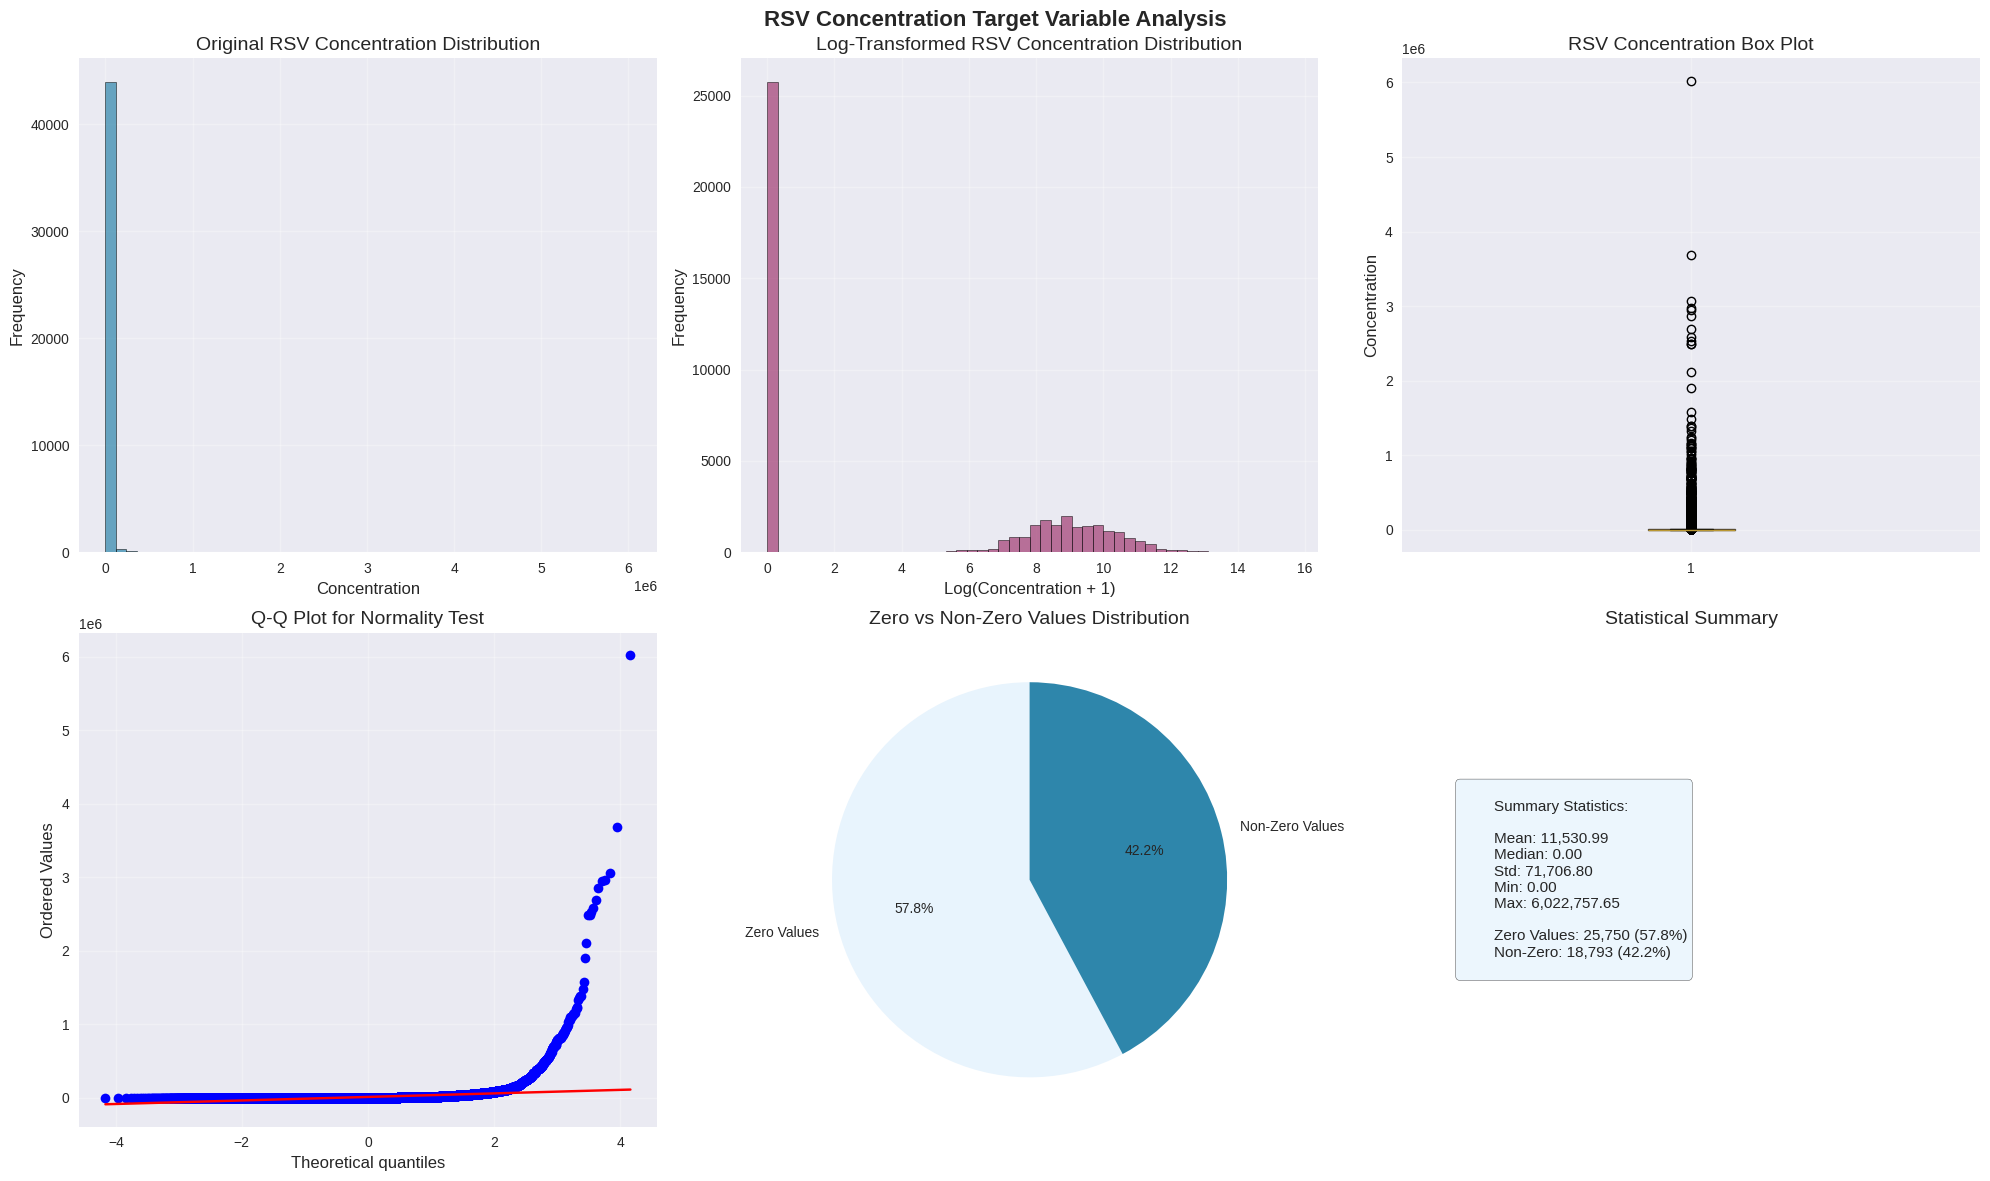

✅ Target Distribution Analysis saved
Creating Key Numerical Distributions...


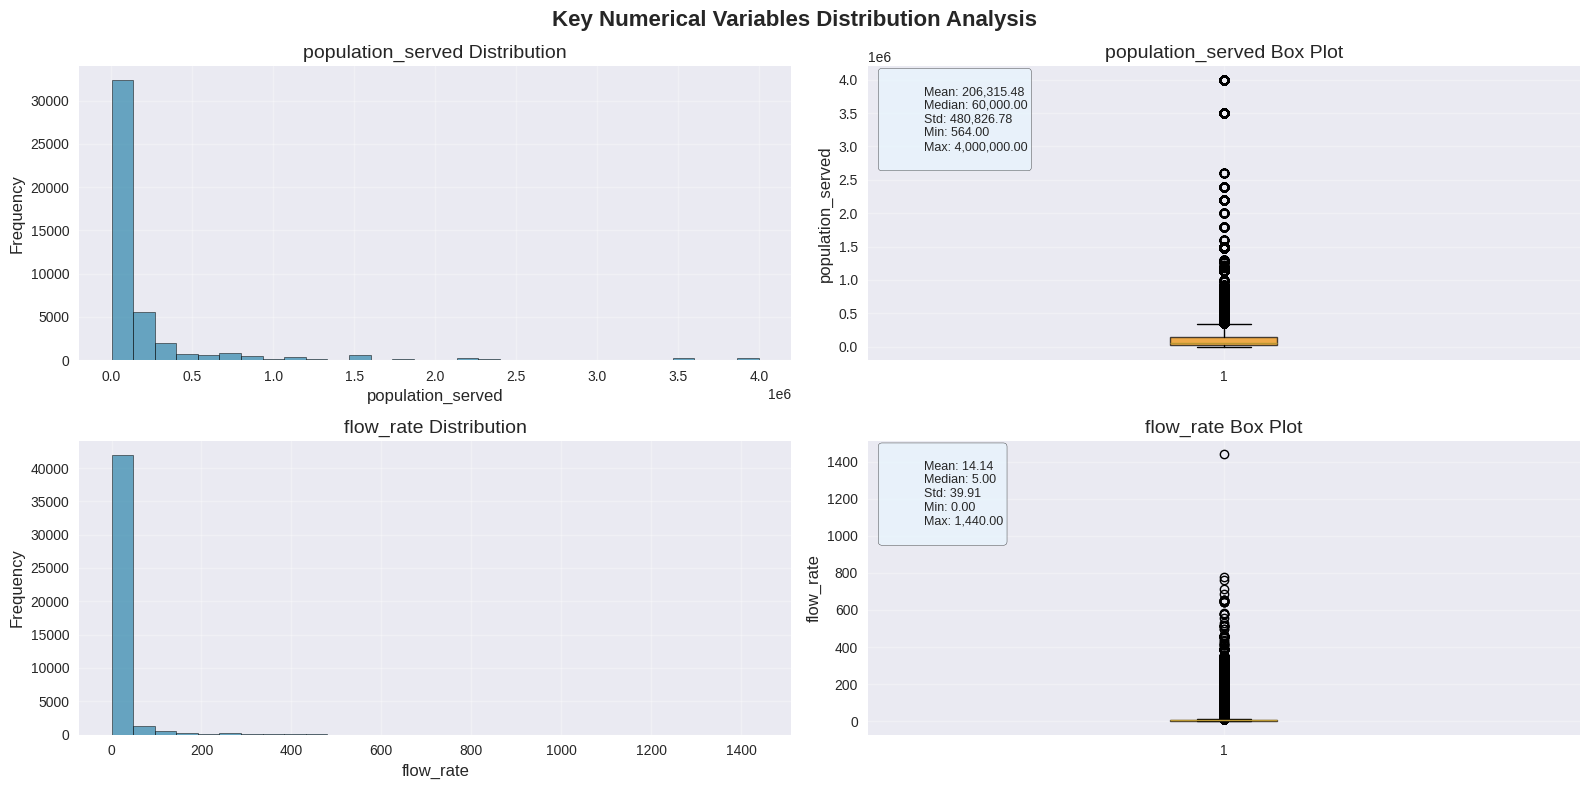

✅ Key Numerical Distributions saved
Creating Correlation Matrix...


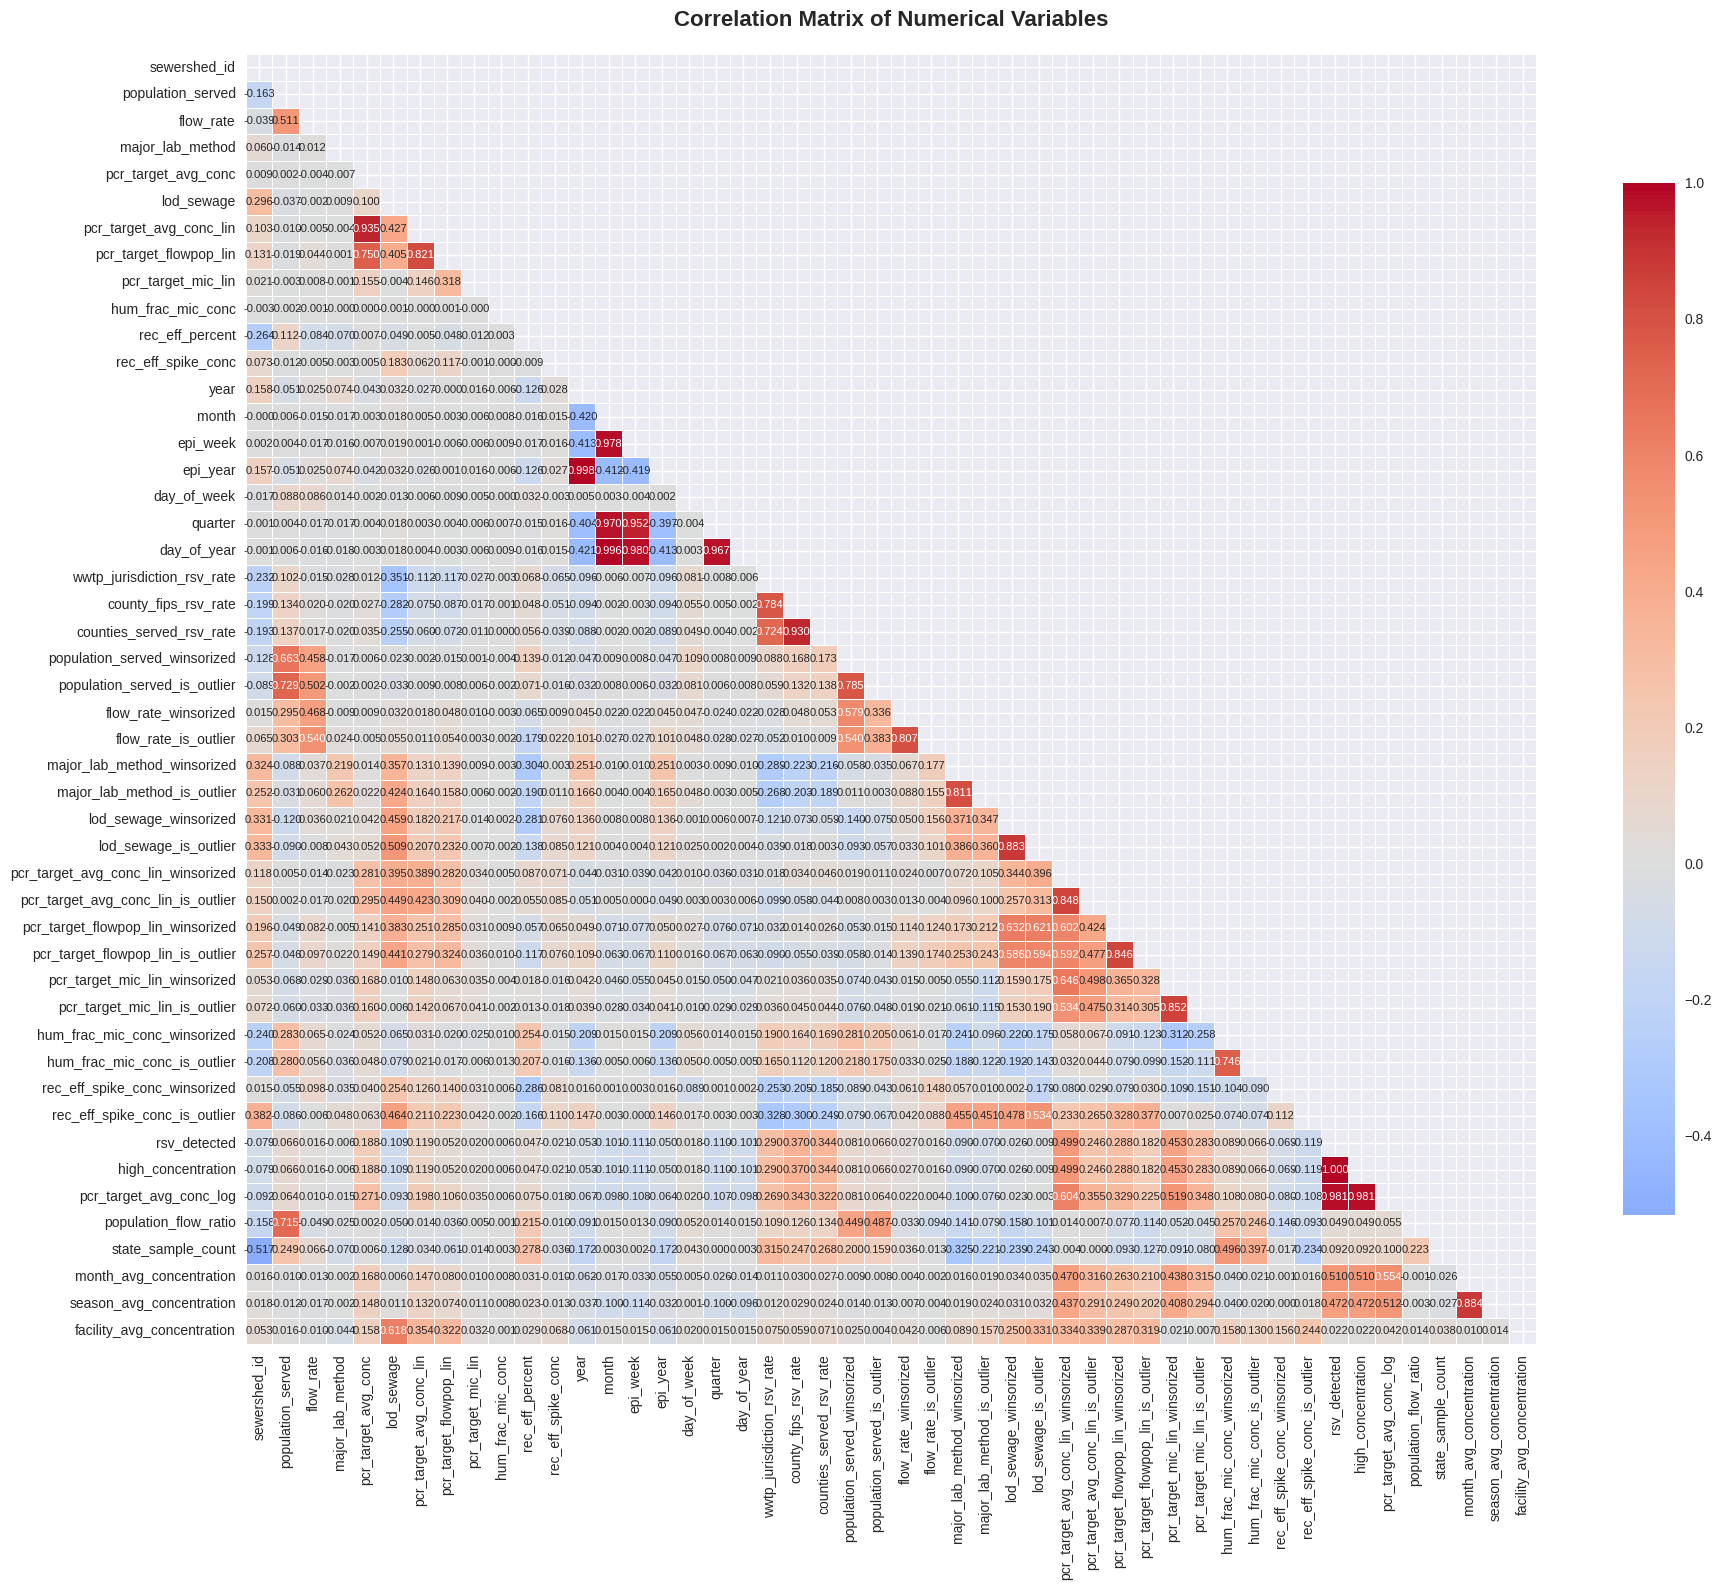

✅ Correlation Matrix saved
Creating Target Correlations...


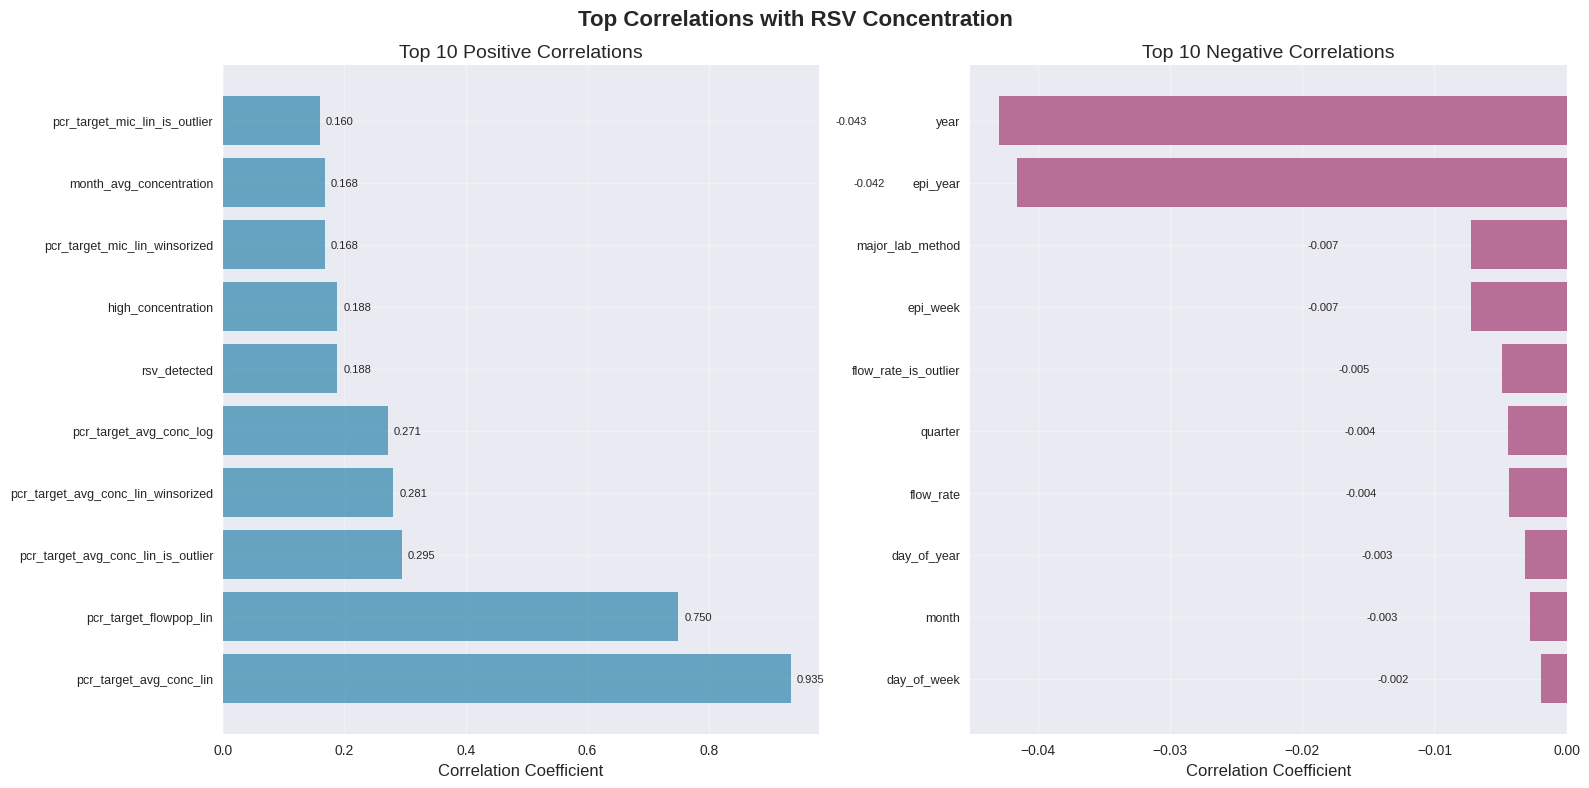

✅ Target Correlations saved
Creating Monthly Patterns...


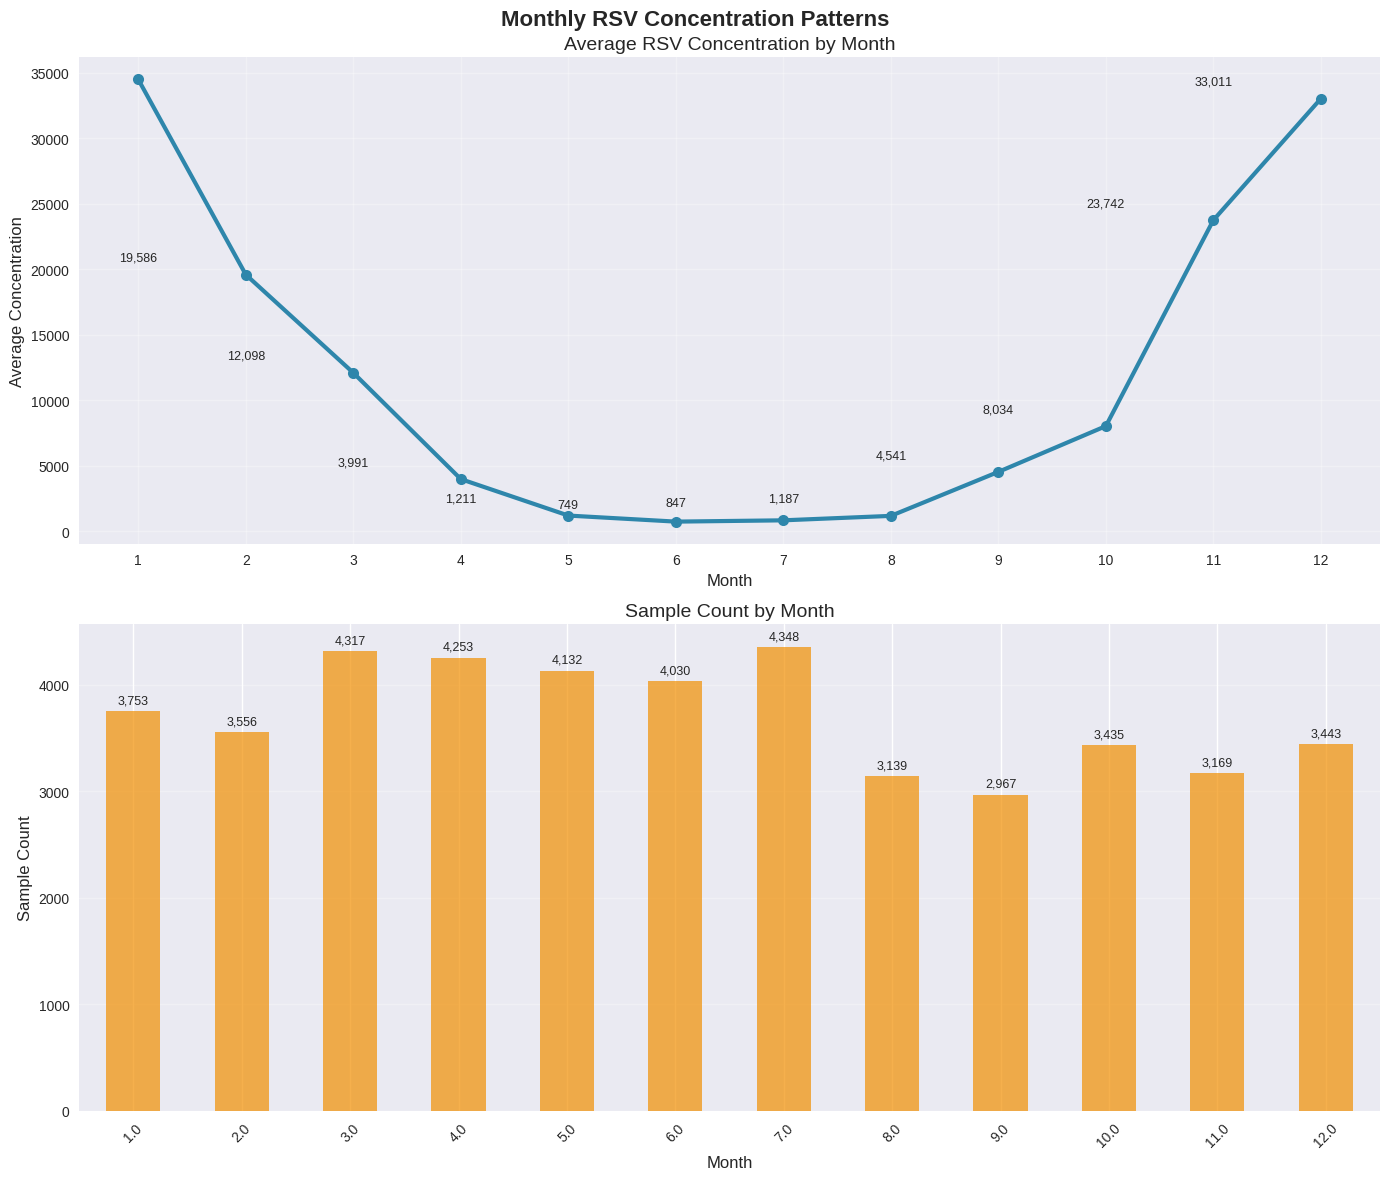

✅ Monthly Patterns saved
Creating Seasonal Patterns...


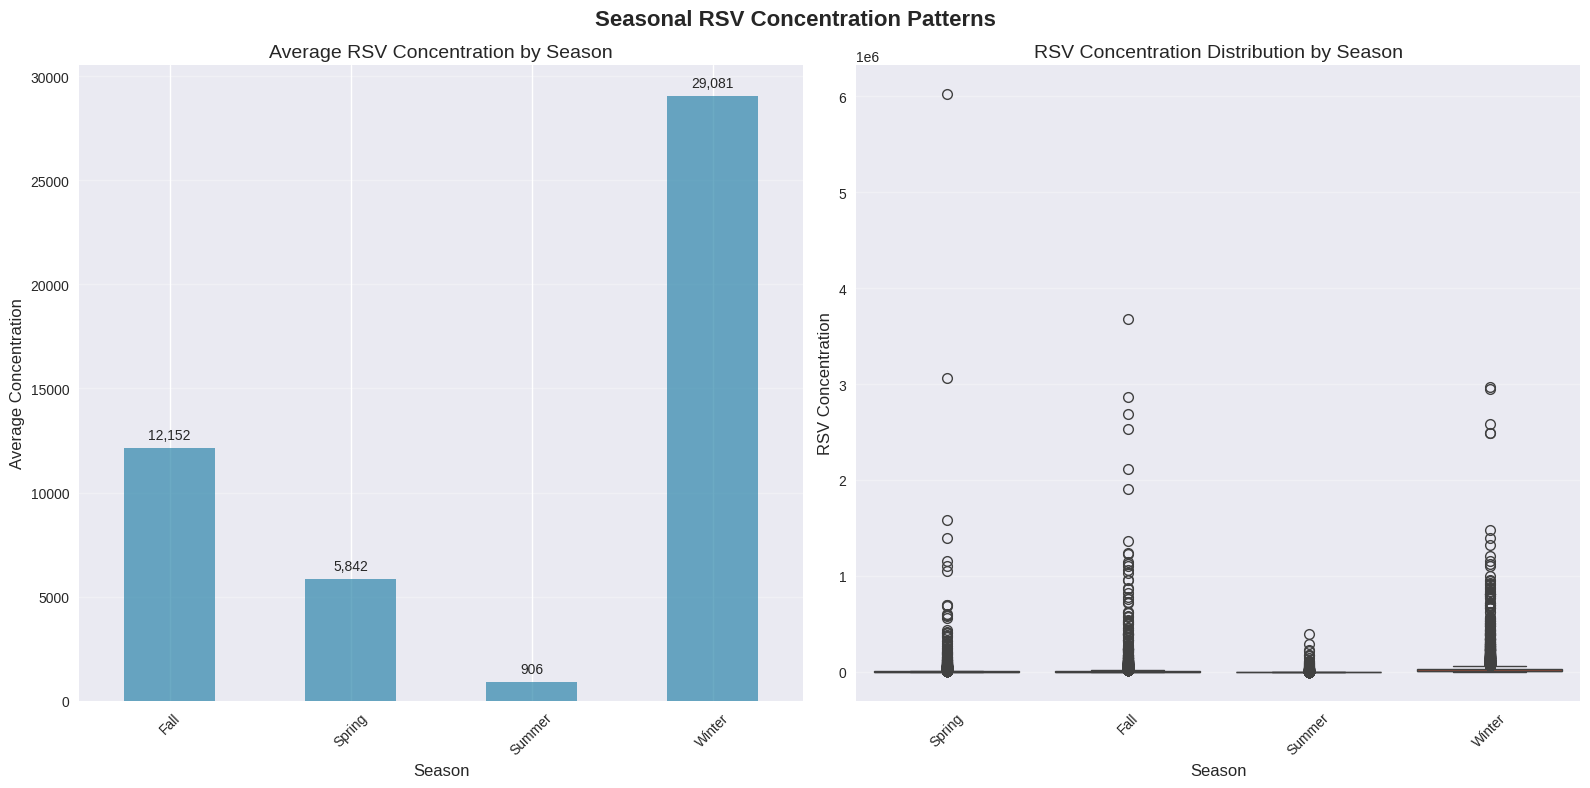

✅ Seasonal Patterns saved
Creating Outlier Analysis...


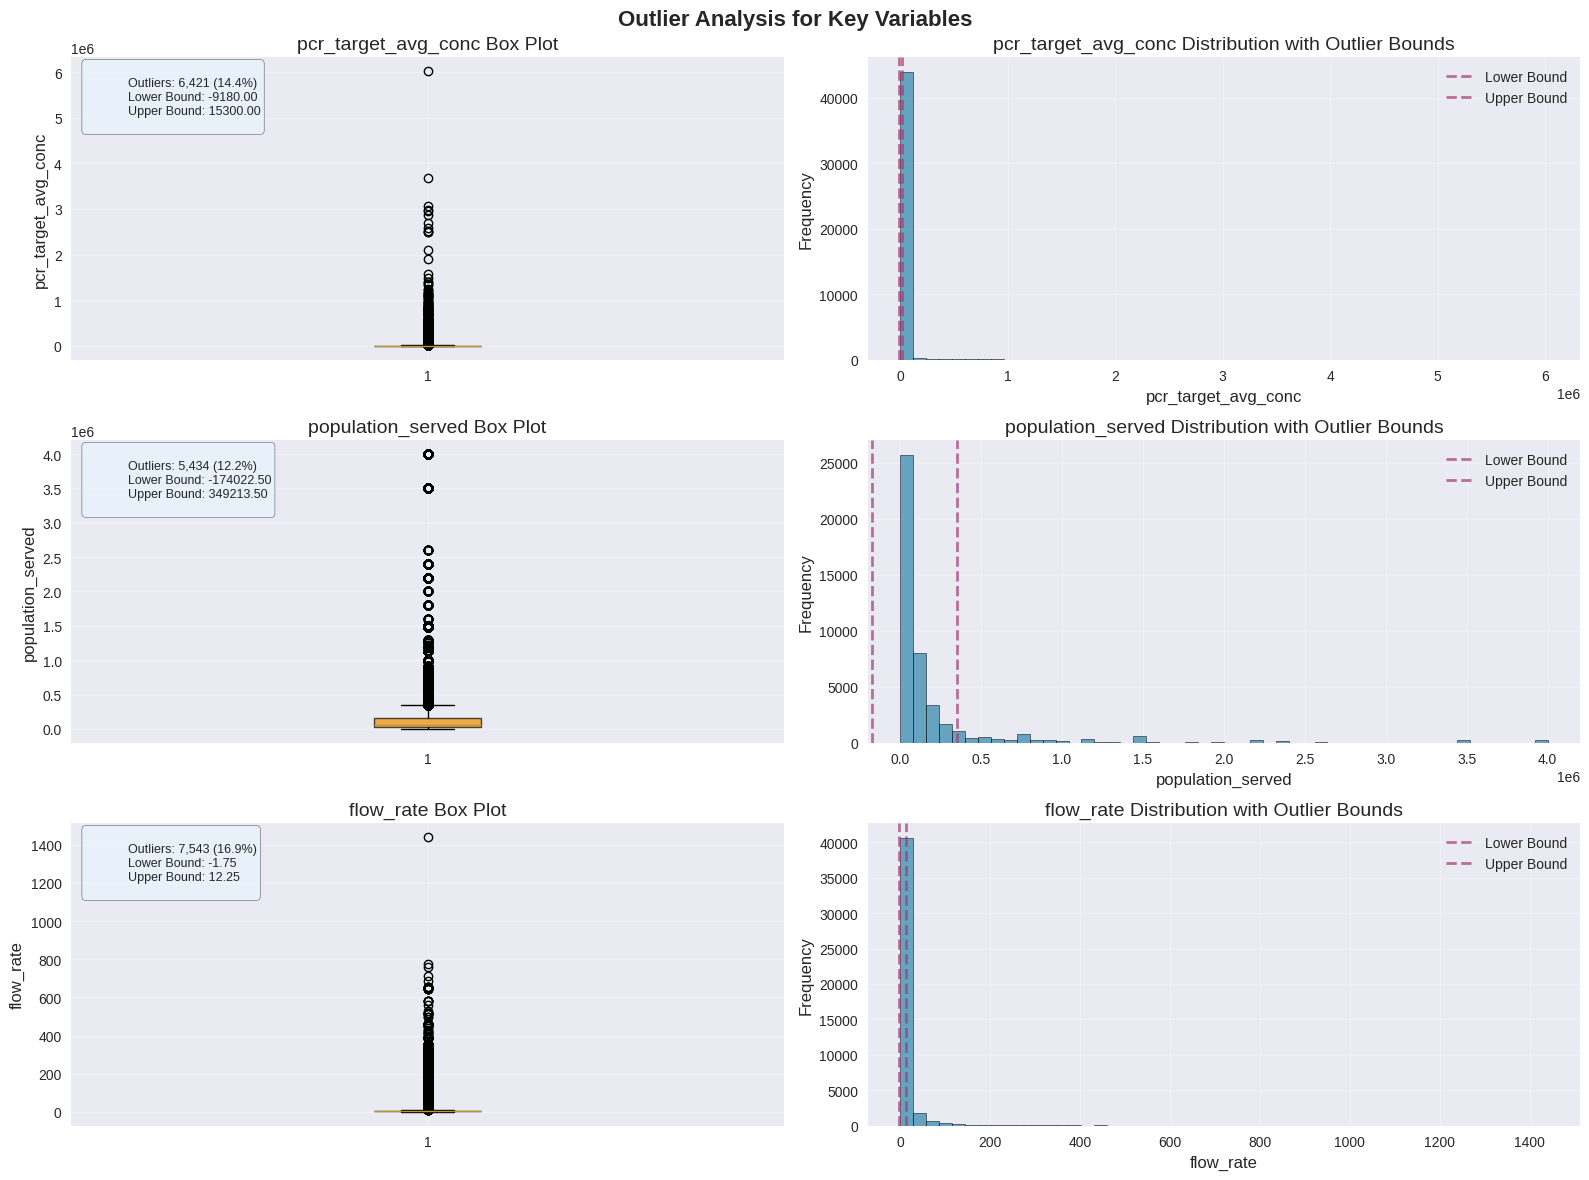

✅ Outlier Analysis saved
Creating Interaction Feature Analysis...


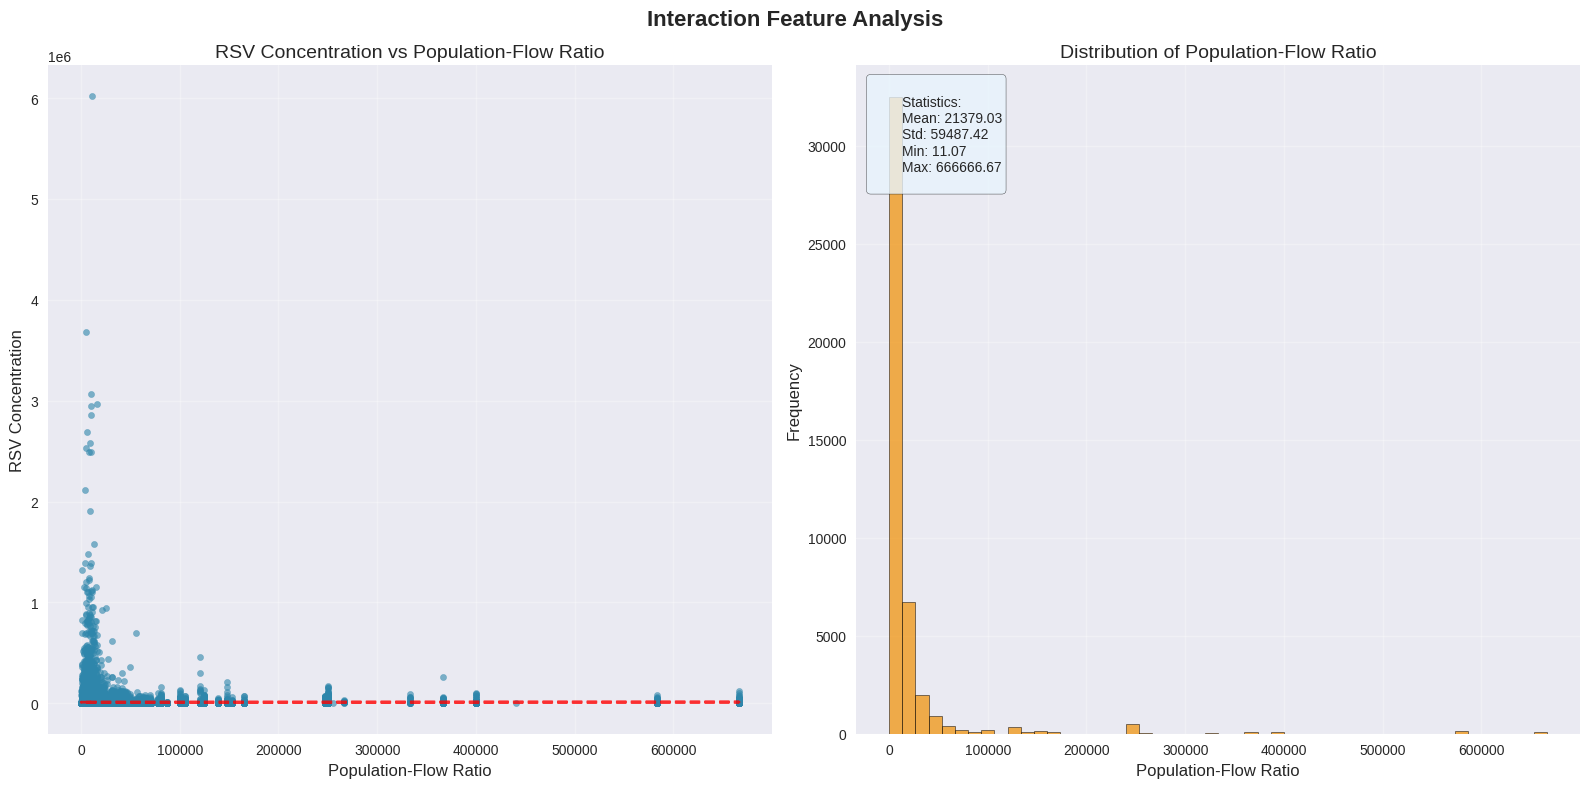

✅ Interaction Feature Analysis saved
Creating Categorical Analysis...


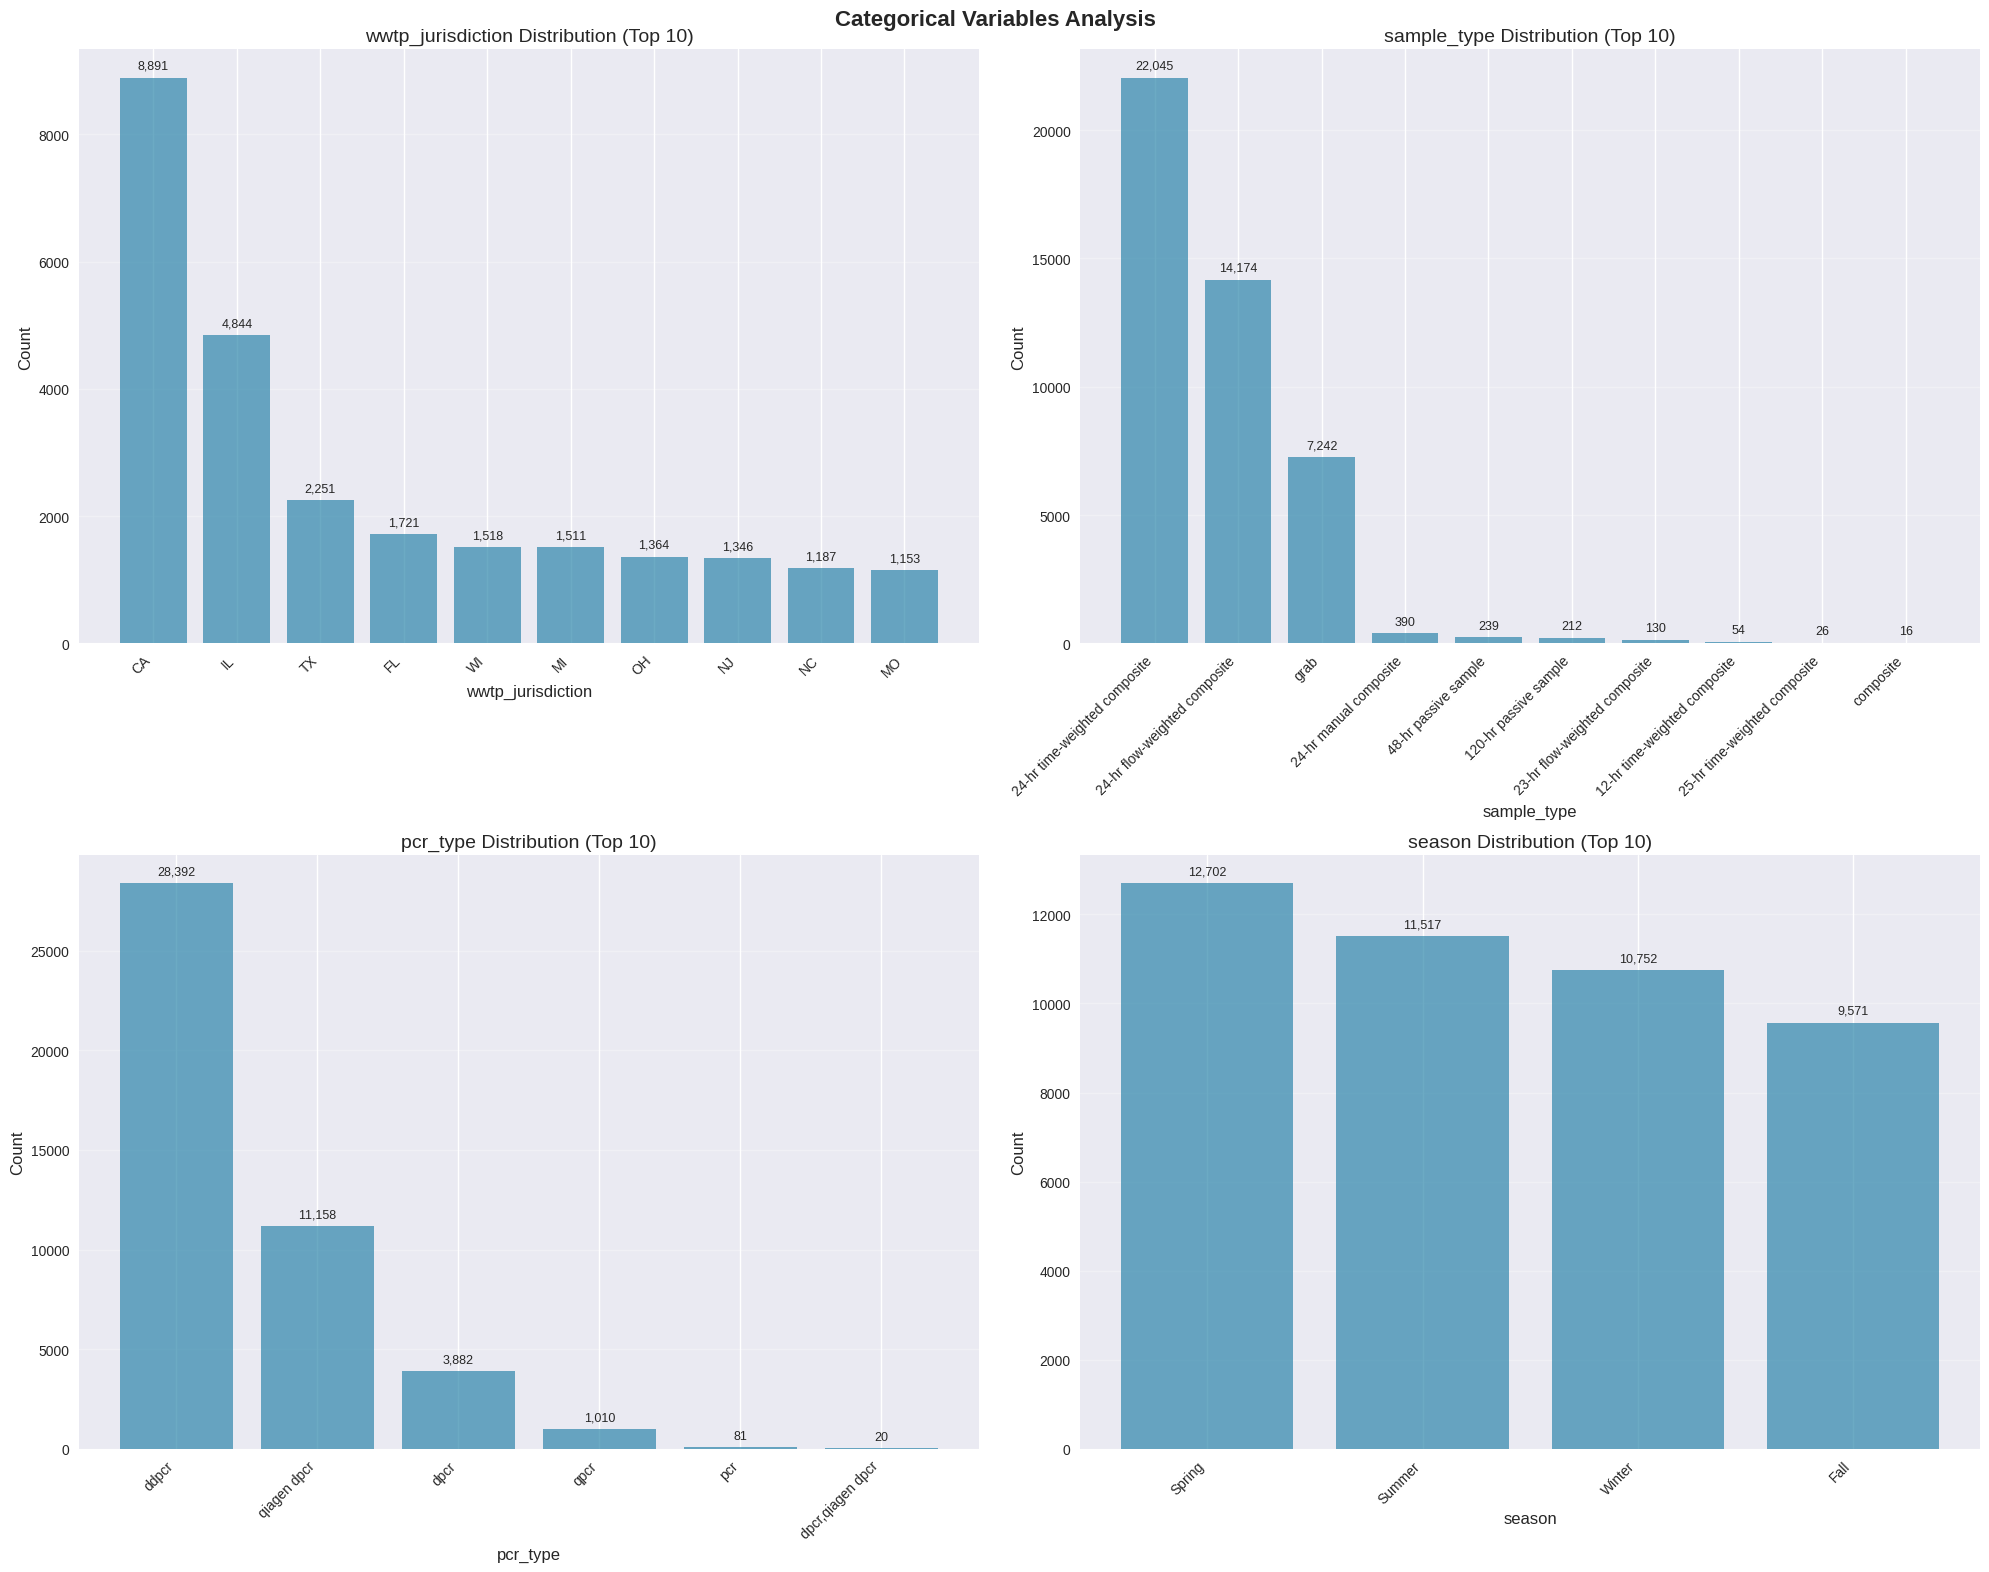

✅ Categorical Analysis saved
Creating Comprehensive Summary Dashboard...


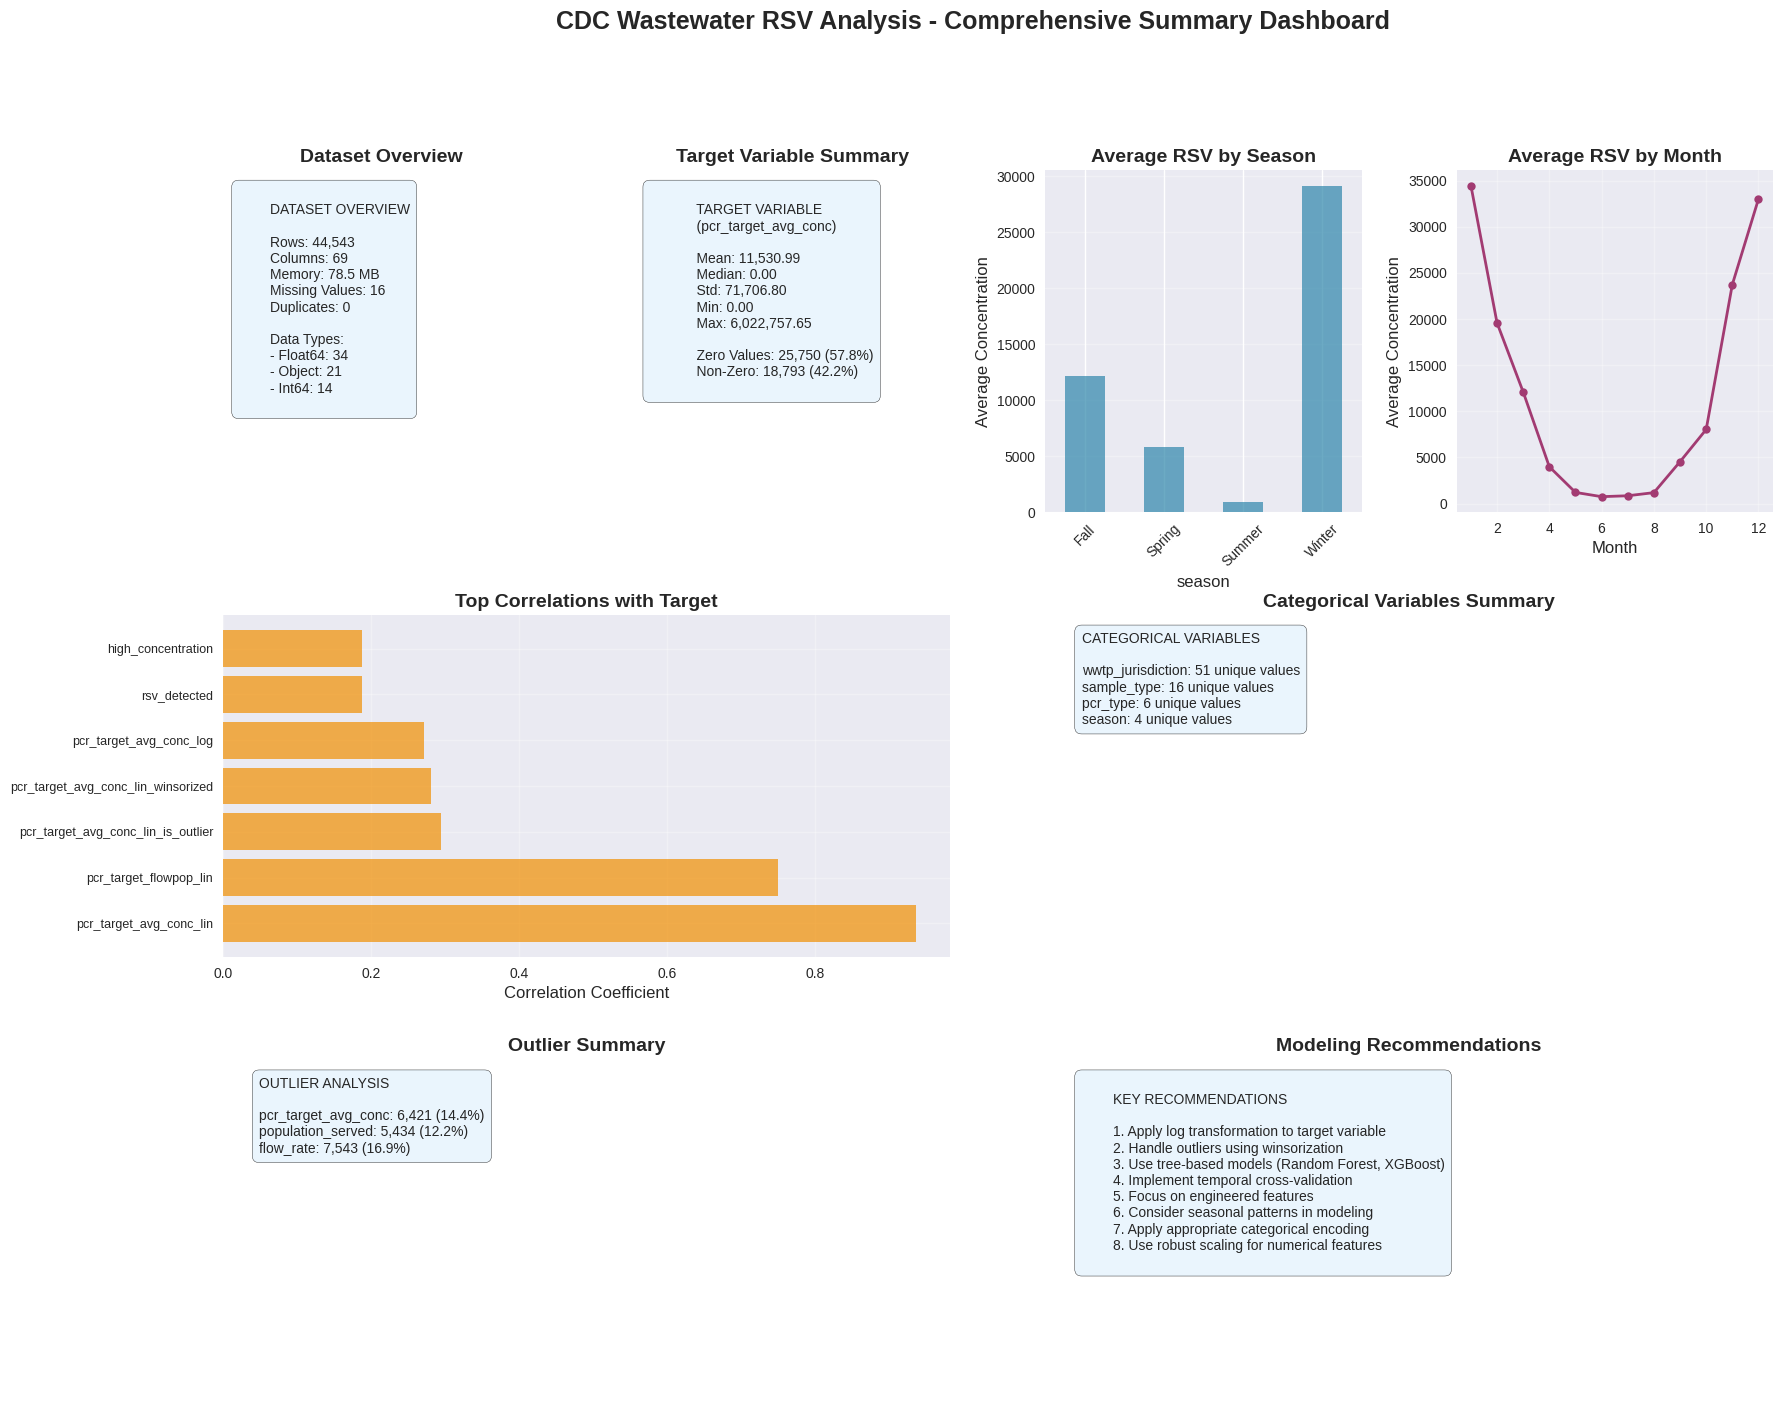

✅ Comprehensive Summary Dashboard saved

🎉 ALL VISUALIZATIONS COMPLETED!
📊 Generated 10 comprehensive visualizations:
   1. Target Distribution Analysis
   2. Key Numerical Distributions
   3. Correlation Matrix
   4. Target Correlations
   5. Monthly Patterns
   6. Seasonal Patterns
   7. Outlier Analysis
   8. Interaction Feature Analysis
   9. Categorical Analysis
   10. Comprehensive Summary Dashboard

✅ All plots saved as high-resolution PNG files (300 DPI)


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style for professional visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

class ComprehensiveVisualizations:
    """
    Comprehensive Visualization Suite for CDC Wastewater RSV Analysis
    Generates all plots from the EDA analysis with professional styling
    """

    def __init__(self, data_path='cdc_wastewater_eda_ready.csv'):
        self.data_path = data_path
        self.df = None
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'accent': '#F18F01',
            'success': '#C73E1D',
            'light': '#E8F4FD',
            'dark': '#1B1B1B'
        }

    def load_data(self):
        """Load the dataset"""
        print("Loading dataset for visualization...")
        try:
            self.df = pd.read_csv(self.data_path)
            print(f"✅ Data loaded: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")
            return True
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            return False

    def plot_1_target_distribution_analysis(self):
        """
        PLOT 1: Target Variable Distribution Analysis
        Comprehensive analysis of the RSV concentration target variable
        """
        print("Creating Target Distribution Analysis...")

        if 'pcr_target_avg_conc' not in self.df.columns:
            print("❌ Target variable not found")
            return

        target = self.df['pcr_target_avg_conc']

        # Create comprehensive target analysis
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('RSV Concentration Target Variable Analysis', fontsize=16, fontweight='bold', y=0.98)

        # 1. Original distribution histogram
        axes[0, 0].hist(target, bins=50, alpha=0.7, color=self.colors['primary'], edgecolor='black', linewidth=0.5)
        axes[0, 0].set_title('Original RSV Concentration Distribution')
        axes[0, 0].set_xlabel('Concentration')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Log-transformed distribution
        if 'pcr_target_avg_conc_log' in self.df.columns:
            log_target = self.df['pcr_target_avg_conc_log']
            axes[0, 1].hist(log_target, bins=50, alpha=0.7, color=self.colors['secondary'], edgecolor='black', linewidth=0.5)
            axes[0, 1].set_title('Log-Transformed RSV Concentration Distribution')
            axes[0, 1].set_xlabel('Log(Concentration + 1)')
            axes[0, 1].set_ylabel('Frequency')
            axes[0, 1].grid(True, alpha=0.3)

        # 3. Box plot
        axes[0, 2].boxplot(target.dropna(), patch_artist=True,
                          boxprops=dict(facecolor=self.colors['accent'], alpha=0.7))
        axes[0, 2].set_title('RSV Concentration Box Plot')
        axes[0, 2].set_ylabel('Concentration')
        axes[0, 2].grid(True, alpha=0.3)

        # 4. Q-Q plot for normality
        from scipy import stats
        stats.probplot(target.dropna(), dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title('Q-Q Plot for Normality Test')
        axes[1, 0].grid(True, alpha=0.3)

        # 5. Zero vs Non-zero analysis
        zero_count = (target == 0).sum()
        non_zero_count = (target > 0).sum()
        total_count = len(target)

        labels = ['Zero Values', 'Non-Zero Values']
        sizes = [zero_count, non_zero_count]
        colors_pie = [self.colors['light'], self.colors['primary']]

        axes[1, 1].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
        axes[1, 1].set_title('Zero vs Non-Zero Values Distribution')

        # 6. Summary statistics
        stats_text = f"""
        Summary Statistics:

        Mean: {target.mean():,.2f}
        Median: {target.median():,.2f}
        Std: {target.std():,.2f}
        Min: {target.min():,.2f}
        Max: {target.max():,.2f}

        Zero Values: {zero_count:,} ({zero_count/total_count*100:.1f}%)
        Non-Zero: {non_zero_count:,} ({non_zero_count/total_count*100:.1f}%)
        """

        axes[1, 2].text(0.1, 0.5, stats_text, transform=axes[1, 2].transAxes,
                       fontsize=11, verticalalignment='center',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor=self.colors['light'], alpha=0.8))
        axes[1, 2].set_title('Statistical Summary')
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.savefig('target_distribution_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Target Distribution Analysis saved")

    def plot_2_key_numerical_distributions(self):
        """
        PLOT 2: Key Numerical Variables Distribution
        Distribution analysis of important numerical features
        """
        print("Creating Key Numerical Distributions...")

        numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        key_numerical = ['population_served', 'flow_rate', 'sample_volume_ml']
        key_numerical = [col for col in key_numerical if col in numerical_cols]

        if not key_numerical:
            print("❌ No key numerical variables found")
            return

        fig, axes = plt.subplots(len(key_numerical), 2, figsize=(16, 4*len(key_numerical)))
        if len(key_numerical) == 1:
            axes = axes.reshape(1, -1)

        fig.suptitle('Key Numerical Variables Distribution Analysis', fontsize=16, fontweight='bold', y=0.98)

        for i, col in enumerate(key_numerical):
            data = self.df[col].dropna()

            # Histogram
            axes[i, 0].hist(data, bins=30, alpha=0.7, color=self.colors['primary'], edgecolor='black', linewidth=0.5)
            axes[i, 0].set_title(f'{col} Distribution')
            axes[i, 0].set_xlabel(col)
            axes[i, 0].set_ylabel('Frequency')
            axes[i, 0].grid(True, alpha=0.3)

            # Box plot
            box_plot = axes[i, 1].boxplot(data, patch_artist=True,
                                         boxprops=dict(facecolor=self.colors['accent'], alpha=0.7))
            axes[i, 1].set_title(f'{col} Box Plot')
            axes[i, 1].set_ylabel(col)
            axes[i, 1].grid(True, alpha=0.3)

            # Add statistics text
            stats_text = f"""
            Mean: {data.mean():,.2f}
            Median: {data.median():,.2f}
            Std: {data.std():,.2f}
            Min: {data.min():,.2f}
            Max: {data.max():,.2f}
            """

            # Add text box
            axes[i, 1].text(0.02, 0.98, stats_text, transform=axes[i, 1].transAxes,
                           fontsize=9, verticalalignment='top',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor=self.colors['light'], alpha=0.8))

        plt.tight_layout()
        plt.savefig('key_numerical_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Key Numerical Distributions saved")

    def plot_3_correlation_matrix(self):
        """
        PLOT 3: Correlation Matrix Heatmap
        Comprehensive correlation analysis of all numerical variables
        """
        print("Creating Correlation Matrix...")

        numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()

        if len(numerical_cols) < 2:
            print("❌ Not enough numerical variables for correlation")
            return

        # Create correlation matrix
        corr_matrix = self.df[numerical_cols].corr()

        # Create the heatmap
        plt.figure(figsize=(20, 16))

        # Create mask for upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Create heatmap
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.3f',
                    annot_kws={'size': 8})

        plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Correlation Matrix saved")

    def plot_4_target_correlations(self):
        """
        PLOT 4: Target Variable Correlations
        Top correlations with the target variable
        """
        print("Creating Target Correlations...")

        if 'pcr_target_avg_conc' not in self.df.columns:
            print("❌ Target variable not found")
            return

        numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        corr_matrix = self.df[numerical_cols].corr()
        target_corr = corr_matrix['pcr_target_avg_conc'].sort_values(ascending=False)

        # Get top positive and negative correlations
        top_corr = target_corr.head(11)[1:11]  # Exclude target itself
        bottom_corr = target_corr.tail(10)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        fig.suptitle('Top Correlations with RSV Concentration', fontsize=16, fontweight='bold')

        # Top positive correlations
        bars1 = ax1.barh(range(len(top_corr)), top_corr.values, color=self.colors['primary'], alpha=0.7)
        ax1.set_yticks(range(len(top_corr)))
        ax1.set_yticklabels(top_corr.index, fontsize=9)
        ax1.set_xlabel('Correlation Coefficient')
        ax1.set_title('Top 10 Positive Correlations')
        ax1.grid(True, alpha=0.3)

        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars1, top_corr.values)):
            ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{value:.3f}', ha='left', va='center', fontsize=8)

        # Top negative correlations
        bars2 = ax2.barh(range(len(bottom_corr)), bottom_corr.values, color=self.colors['secondary'], alpha=0.7)
        ax2.set_yticks(range(len(bottom_corr)))
        ax2.set_yticklabels(bottom_corr.index, fontsize=9)
        ax2.set_xlabel('Correlation Coefficient')
        ax2.set_title('Top 10 Negative Correlations')
        ax2.grid(True, alpha=0.3)

        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars2, bottom_corr.values)):
            ax2.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                    f'{value:.3f}', ha='right', va='center', fontsize=8)

        plt.tight_layout()
        plt.savefig('target_correlations.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Target Correlations saved")

    def plot_5_monthly_patterns(self):
        """
        PLOT 5: Monthly Patterns Analysis
        Temporal analysis by month
        """
        print("Creating Monthly Patterns...")

        if 'month' not in self.df.columns or 'pcr_target_avg_conc' not in self.df.columns:
            print("❌ Month or target variable not found")
            return

        # Calculate monthly statistics
        monthly_stats = self.df.groupby('month')['pcr_target_avg_conc'].agg(['count', 'mean', 'std', 'median']).round(2)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
        fig.suptitle('Monthly RSV Concentration Patterns', fontsize=16, fontweight='bold')

        # Line plot of monthly averages
        monthly_stats['mean'].plot(kind='line', marker='o', color=self.colors['primary'],
                                 linewidth=3, markersize=8, ax=ax1)
        ax1.set_title('Average RSV Concentration by Month')
        ax1.set_xlabel('Month')
        ax1.set_ylabel('Average Concentration')
        ax1.grid(True, alpha=0.3)
        ax1.set_xticks(range(1, 13))

        # Add value labels on points
        for i, (month, value) in enumerate(monthly_stats['mean'].items()):
            ax1.annotate(f'{value:,.0f}', (i, value), textcoords="offset points",
                        xytext=(0,10), ha='center', fontsize=9)

        # Bar plot with sample counts
        monthly_stats['count'].plot(kind='bar', color=self.colors['accent'], alpha=0.7, ax=ax2)
        ax2.set_title('Sample Count by Month')
        ax2.set_xlabel('Month')
        ax2.set_ylabel('Sample Count')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for i, (month, value) in enumerate(monthly_stats['count'].items()):
            ax2.text(i, value + max(monthly_stats['count']) * 0.01, f'{value:,}',
                    ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.savefig('monthly_patterns.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Monthly Patterns saved")

    def plot_6_seasonal_patterns(self):
        """
        PLOT 6: Seasonal Patterns Analysis
        Seasonal analysis of RSV concentration
        """
        print("Creating Seasonal Patterns...")

        if 'season' not in self.df.columns or 'pcr_target_avg_conc' not in self.df.columns:
            print("❌ Season or target variable not found")
            return

        # Calculate seasonal statistics
        seasonal_stats = self.df.groupby('season')['pcr_target_avg_conc'].agg(['count', 'mean', 'std', 'median']).round(2)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        fig.suptitle('Seasonal RSV Concentration Patterns', fontsize=16, fontweight='bold')

        # Bar plot of seasonal averages
        seasonal_stats['mean'].plot(kind='bar', color=self.colors['primary'], alpha=0.7, ax=ax1)
        ax1.set_title('Average RSV Concentration by Season')
        ax1.set_xlabel('Season')
        ax1.set_ylabel('Average Concentration')
        ax1.tick_params(axis='x', rotation=45)
        ax1.grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for i, (season, value) in enumerate(seasonal_stats['mean'].items()):
            ax1.text(i, value + max(seasonal_stats['mean']) * 0.01, f'{value:,.0f}',
                    ha='center', va='bottom', fontsize=10)

        # Box plot by season
        sns.boxplot(data=self.df, x='season', y='pcr_target_avg_conc', ax=ax2,
                   palette=[self.colors['primary'], self.colors['secondary'],
                           self.colors['accent'], self.colors['success']])
        ax2.set_title('RSV Concentration Distribution by Season')
        ax2.set_xlabel('Season')
        ax2.set_ylabel('RSV Concentration')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('seasonal_patterns.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Seasonal Patterns saved")

    def plot_7_outlier_analysis(self):
        """
        PLOT 7: Outlier Analysis
        Comprehensive outlier detection and visualization
        """
        print("Creating Outlier Analysis...")

        numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        key_numerical = ['pcr_target_avg_conc', 'population_served', 'flow_rate']
        key_numerical = [col for col in key_numerical if col in numerical_cols]

        if not key_numerical:
            print("❌ No key numerical variables found")
            return

        fig, axes = plt.subplots(len(key_numerical), 2, figsize=(16, 4*len(key_numerical)))
        if len(key_numerical) == 1:
            axes = axes.reshape(1, -1)

        fig.suptitle('Outlier Analysis for Key Variables', fontsize=16, fontweight='bold', y=0.98)

        for i, col in enumerate(key_numerical):
            data = self.df[col].dropna()

            # Calculate outlier bounds
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Count outliers
            outliers = ((data < lower_bound) | (data > upper_bound)).sum()
            outlier_percent = (outliers / len(data)) * 100

            # Box plot
            box_plot = axes[i, 0].boxplot(data, patch_artist=True,
                                         boxprops=dict(facecolor=self.colors['accent'], alpha=0.7))
            axes[i, 0].set_title(f'{col} Box Plot')
            axes[i, 0].set_ylabel(col)
            axes[i, 0].grid(True, alpha=0.3)

            # Add outlier statistics
            stats_text = f"""
            Outliers: {outliers:,} ({outlier_percent:.1f}%)
            Lower Bound: {lower_bound:.2f}
            Upper Bound: {upper_bound:.2f}
            """
            axes[i, 0].text(0.02, 0.98, stats_text, transform=axes[i, 0].transAxes,
                           fontsize=9, verticalalignment='top',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor=self.colors['light'], alpha=0.8))

            # Histogram with outlier bounds
            axes[i, 1].hist(data, bins=50, alpha=0.7, color=self.colors['primary'], edgecolor='black', linewidth=0.5)
            axes[i, 1].axvline(lower_bound, color=self.colors['secondary'], linestyle='--', alpha=0.7, linewidth=2, label='Lower Bound')
            axes[i, 1].axvline(upper_bound, color=self.colors['secondary'], linestyle='--', alpha=0.7, linewidth=2, label='Upper Bound')
            axes[i, 1].set_title(f'{col} Distribution with Outlier Bounds')
            axes[i, 1].set_xlabel(col)
            axes[i, 1].set_ylabel('Frequency')
            axes[i, 1].legend()
            axes[i, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Outlier Analysis saved")

    def plot_8_interaction_feature_analysis(self):
        """
        PLOT 8: Interaction Feature Analysis
        Analysis of interaction features and their relationships
        """
        print("Creating Interaction Feature Analysis...")

        if 'population_flow_ratio' not in self.df.columns or 'pcr_target_avg_conc' not in self.df.columns:
            print("❌ Interaction features not found")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        fig.suptitle('Interaction Feature Analysis', fontsize=16, fontweight='bold')

        # Scatter plot of population-flow ratio vs target
        ax1.scatter(self.df['population_flow_ratio'], self.df['pcr_target_avg_conc'],
                   alpha=0.6, color=self.colors['primary'], s=20)
        ax1.set_xlabel('Population-Flow Ratio')
        ax1.set_ylabel('RSV Concentration')
        ax1.set_title('RSV Concentration vs Population-Flow Ratio')
        ax1.grid(True, alpha=0.3)

        # Add trend line
        z = np.polyfit(self.df['population_flow_ratio'].dropna(),
                      self.df['pcr_target_avg_conc'].dropna(), 1)
        p = np.poly1d(z)
        ax1.plot(self.df['population_flow_ratio'], p(self.df['population_flow_ratio']),
                "r--", alpha=0.8, linewidth=2)

        # Distribution of population-flow ratio
        ax2.hist(self.df['population_flow_ratio'].dropna(), bins=50, alpha=0.7,
                color=self.colors['accent'], edgecolor='black', linewidth=0.5)
        ax2.set_xlabel('Population-Flow Ratio')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Distribution of Population-Flow Ratio')
        ax2.grid(True, alpha=0.3)

        # Add statistics
        ratio_stats = self.df['population_flow_ratio'].describe()
        stats_text = f"""
        Statistics:
        Mean: {ratio_stats['mean']:.2f}
        Std: {ratio_stats['std']:.2f}
        Min: {ratio_stats['min']:.2f}
        Max: {ratio_stats['max']:.2f}
        """
        ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=self.colors['light'], alpha=0.8))

        plt.tight_layout()
        plt.savefig('interaction_feature_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Interaction Feature Analysis saved")

    def plot_9_categorical_analysis(self):
        """
        PLOT 9: Categorical Variables Analysis
        Comprehensive analysis of categorical variables
        """
        print("Creating Categorical Analysis...")

        categorical_cols = self.df.select_dtypes(include=['object']).columns.tolist()
        key_categoricals = ['wwtp_jurisdiction', 'sample_type', 'pcr_type', 'season']
        key_categoricals = [col for col in key_categoricals if col in categorical_cols]

        if not key_categoricals:
            print("❌ No key categorical variables found")
            return

        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        fig.suptitle('Categorical Variables Analysis', fontsize=16, fontweight='bold', y=0.98)

        for i, col in enumerate(key_categoricals):
            row = i // 2
            col_idx = i % 2

            value_counts = self.df[col].value_counts().head(10)

            # Create bar plot
            bars = axes[row, col_idx].bar(range(len(value_counts)), value_counts.values,
                                        color=self.colors['primary'], alpha=0.7)
            axes[row, col_idx].set_title(f'{col} Distribution (Top 10)')
            axes[row, col_idx].set_xlabel(col)
            axes[row, col_idx].set_ylabel('Count')
            axes[row, col_idx].set_xticks(range(len(value_counts)))
            axes[row, col_idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[row, col_idx].grid(axis='y', alpha=0.3)

            # Add value labels on bars
            for j, (bar, value) in enumerate(zip(bars, value_counts.values)):
                axes[row, col_idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(value_counts.values) * 0.01,
                                      f'{value:,}', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.savefig('categorical_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Categorical Analysis saved")

    def plot_10_comprehensive_summary(self):
        """
        PLOT 10: Comprehensive Summary Dashboard
        Summary dashboard with key insights
        """
        print("Creating Comprehensive Summary Dashboard...")

        fig = plt.figure(figsize=(20, 16))
        fig.suptitle('CDC Wastewater RSV Analysis - Comprehensive Summary Dashboard',
                    fontsize=18, fontweight='bold', y=0.98)

        # Create grid layout
        gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

        # 1. Dataset overview
        ax1 = fig.add_subplot(gs[0, 0])
        overview_text = f"""
        DATASET OVERVIEW

        Rows: {len(self.df):,}
        Columns: {len(self.df.columns)}
        Memory: {self.df.memory_usage(deep=True).sum() / 1024**2:.1f} MB
        Missing Values: {self.df.isnull().sum().sum():,}
        Duplicates: {self.df.duplicated().sum():,}

        Data Types:
        - Float64: {len(self.df.select_dtypes(include=['float64']).columns)}
        - Object: {len(self.df.select_dtypes(include=['object']).columns)}
        - Int64: {len(self.df.select_dtypes(include=['int64']).columns)}
        """
        ax1.text(0.05, 0.95, overview_text, transform=ax1.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5",
                facecolor=self.colors['light'], alpha=0.9))
        ax1.set_title('Dataset Overview', fontweight='bold')
        ax1.axis('off')

        # 2. Target variable summary
        if 'pcr_target_avg_conc' in self.df.columns:
            target = self.df['pcr_target_avg_conc']
            ax2 = fig.add_subplot(gs[0, 1])
            target_text = f"""
            TARGET VARIABLE
            (pcr_target_avg_conc)

            Mean: {target.mean():,.2f}
            Median: {target.median():,.2f}
            Std: {target.std():,.2f}
            Min: {target.min():,.2f}
            Max: {target.max():,.2f}

            Zero Values: {(target == 0).sum():,} ({(target == 0).sum() / len(target) * 100:.1f}%)
            Non-Zero: {(target > 0).sum():,} ({(target > 0).sum() / len(target) * 100:.1f}%)
            """
            ax2.text(0.05, 0.95, target_text, transform=ax2.transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5",
                    facecolor=self.colors['light'], alpha=0.9))
            ax2.set_title('Target Variable Summary', fontweight='bold')
            ax2.axis('off')

        # 3. Seasonal patterns
        if 'season' in self.df.columns and 'pcr_target_avg_conc' in self.df.columns:
            ax3 = fig.add_subplot(gs[0, 2])
            seasonal_avg = self.df.groupby('season')['pcr_target_avg_conc'].mean()
            seasonal_avg.plot(kind='bar', color=self.colors['primary'], alpha=0.7, ax=ax3)
            ax3.set_title('Average RSV by Season', fontweight='bold')
            ax3.set_ylabel('Average Concentration')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(axis='y', alpha=0.3)

        # 4. Monthly patterns
        if 'month' in self.df.columns and 'pcr_target_avg_conc' in self.df.columns:
            ax4 = fig.add_subplot(gs[0, 3])
            monthly_avg = self.df.groupby('month')['pcr_target_avg_conc'].mean()
            monthly_avg.plot(kind='line', marker='o', color=self.colors['secondary'],
                           linewidth=2, markersize=6, ax=ax4)
            ax4.set_title('Average RSV by Month', fontweight='bold')
            ax4.set_ylabel('Average Concentration')
            ax4.set_xlabel('Month')
            ax4.grid(True, alpha=0.3)

        # 5. Top correlations
        if 'pcr_target_avg_conc' in self.df.columns:
            ax5 = fig.add_subplot(gs[1, :2])
            numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
            corr_matrix = self.df[numerical_cols].corr()
            target_corr = corr_matrix['pcr_target_avg_conc'].sort_values(ascending=False)
            top_corr = target_corr.head(8)[1:8]  # Exclude target itself

            bars = ax5.barh(range(len(top_corr)), top_corr.values, color=self.colors['accent'], alpha=0.7)
            ax5.set_yticks(range(len(top_corr)))
            ax5.set_yticklabels(top_corr.index, fontsize=9)
            ax5.set_xlabel('Correlation Coefficient')
            ax5.set_title('Top Correlations with Target', fontweight='bold')
            ax5.grid(True, alpha=0.3)

        # 6. Categorical summary
        ax6 = fig.add_subplot(gs[1, 2:])
        categorical_cols = self.df.select_dtypes(include=['object']).columns.tolist()
        key_cats = ['wwtp_jurisdiction', 'sample_type', 'pcr_type', 'season']
        key_cats = [col for col in key_cats if col in categorical_cols]

        cat_summary = []
        for col in key_cats:
            unique_count = self.df[col].nunique()
            cat_summary.append(f"{col}: {unique_count} unique values")

        cat_text = "CATEGORICAL VARIABLES\n\n" + "\n".join(cat_summary)
        ax6.text(0.05, 0.95, cat_text, transform=ax6.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5",
                facecolor=self.colors['light'], alpha=0.9))
        ax6.set_title('Categorical Variables Summary', fontweight='bold')
        ax6.axis('off')

        # 7. Outlier summary
        ax7 = fig.add_subplot(gs[2, :2])
        numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        key_numerical = ['pcr_target_avg_conc', 'population_served', 'flow_rate']
        key_numerical = [col for col in key_numerical if col in numerical_cols]

        outlier_summary = []
        for col in key_numerical:
            data = self.df[col].dropna()
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
            outlier_percent = (outliers / len(data)) * 100
            outlier_summary.append(f"{col}: {outliers:,} ({outlier_percent:.1f}%)")

        outlier_text = "OUTLIER ANALYSIS\n\n" + "\n".join(outlier_summary)
        ax7.text(0.05, 0.95, outlier_text, transform=ax7.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5",
                facecolor=self.colors['light'], alpha=0.9))
        ax7.set_title('Outlier Summary', fontweight='bold')
        ax7.axis('off')

        # 8. Recommendations
        ax8 = fig.add_subplot(gs[2, 2:])
        recommendations = """
        KEY RECOMMENDATIONS

        1. Apply log transformation to target variable
        2. Handle outliers using winsorization
        3. Use tree-based models (Random Forest, XGBoost)
        4. Implement temporal cross-validation
        5. Focus on engineered features
        6. Consider seasonal patterns in modeling
        7. Apply appropriate categorical encoding
        8. Use robust scaling for numerical features
        """
        ax8.text(0.05, 0.95, recommendations, transform=ax8.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5",
                facecolor=self.colors['light'], alpha=0.9))
        ax8.set_title('Modeling Recommendations', fontweight='bold')
        ax8.axis('off')

        plt.tight_layout()
        plt.savefig('comprehensive_summary_dashboard.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Comprehensive Summary Dashboard saved")

    def generate_all_visualizations(self):
        """
        Generate all visualizations in sequence
        """
        print("🚀 GENERATING ALL VISUALIZATIONS")
        print("=" * 60)

        if not self.load_data():
            return

        # Generate all plots
        self.plot_1_target_distribution_analysis()
        self.plot_2_key_numerical_distributions()
        self.plot_3_correlation_matrix()
        self.plot_4_target_correlations()
        self.plot_5_monthly_patterns()
        self.plot_6_seasonal_patterns()
        self.plot_7_outlier_analysis()
        self.plot_8_interaction_feature_analysis()
        self.plot_9_categorical_analysis()
        self.plot_10_comprehensive_summary()

        print("\n" + "=" * 60)
        print("🎉 ALL VISUALIZATIONS COMPLETED!")
        print("=" * 60)
        print("📊 Generated 10 comprehensive visualizations:")
        print("   1. Target Distribution Analysis")
        print("   2. Key Numerical Distributions")
        print("   3. Correlation Matrix")
        print("   4. Target Correlations")
        print("   5. Monthly Patterns")
        print("   6. Seasonal Patterns")
        print("   7. Outlier Analysis")
        print("   8. Interaction Feature Analysis")
        print("   9. Categorical Analysis")
        print("   10. Comprehensive Summary Dashboard")
        print("\n✅ All plots saved as high-resolution PNG files (300 DPI)")

def main():
    """Main function to run all visualizations"""
    print("🚀 Starting Comprehensive Visualization Suite...")

    # Create and run visualization suite
    viz_suite = ComprehensiveVisualizations()
    viz_suite.generate_all_visualizations()

if __name__ == "__main__":
    main()